Trabalho 2 para a cadeira de extração de conhecimento
Autores: Maria Joana Silva e Carina Filipa

Tarefas do trabalho, como no enunciado:

Deverá desenvolver código em Python, organizado num ou vários notebooks, para carregar os
dados, pré-processá-los e realizar um conjunto de análises adequadas aos objetivos do
trabalho. Estes deverão ser incluídos no repositório github do grupo em pasta própria.
O notebook deverá incluir:
1. análise do conjunto de dados e breve descrição dos compostos atribuídos ao grupo;
2. identificação das variáveis correspondentes ao Raman Shift e descrição da estrutura dos
dados;
3. tarefas de pré-processamento dos dados, incluindo tratamento de valores em falta, normalização das intensidades, suavização ou correção de baseline;
4. sumarização dos dados, com estatística descritiva e exploração gráfica dos espectros;
5. comparação visual dos espectros médios dos compostos e identificação de bandas Raman relevantes;
6. análise estatística multivariada não supervisionada, incluindo redução de
dimensionalidade/visualização, por exemplo PCA, t-SNE ou UMAP;
7. clustering dos espectros ou dos compostos, com interpretação dos grupos obtidos;
8. análise preditiva/aprendizagem máquina, por exemplo classificação do composto, da
família química ou de uma propriedade molecular, comparando o desempenho de vários
modelos;
9. validação dos modelos com métricas adequadas e discussão de limitações;
10. seleção ou importância das variáveis usadas pelos modelos, relacionando-as sempre
que possível com regiões relevantes do espectro Raman.

Entrega:
Deverá incluir no repositório do grupo o(s) notebook(s) com todos os métodos utilizados, a
justificação das escolhas efetuadas, o código relevante, os resultados obtidos e a respetiva
interpretação. O trabalho deverá ser suficientemente claro para permitir a reprodução da análise
por outro grupo. A análise deve valorizar não apenas a aplicação de métodos computacionais,
mas também a interpretação dos resultados no contexto da espectroscopia Raman e da
estrutura química dos compostos atribuídos a cada grupo.

A espectroscopia Raman é uma técnica de análise química não destrutiva, que desempenha um papel fundamental no ciclo de análise e descoberta em vários ramos da ciência.

Baseamos a nossa pipeline de analise em RamanSPy, que é um pacote Python de código aberto para investigação e análise em espectroscopia Raman. 

O RamanSPy disponibiliza uma biblioteca abrangente de ferramentas para análise espectroscópica, apoiando tarefas do dia a dia, análises integrativas, o desenvolvimento de métodos e protocolos, e a integração de técnicas avançadas de análise de dados.

O RamanSPy está disponível no GitHub em RamanSPy GitHub - https://github.com/barahona-research-group/RamanSPy, acompanhado de documentação online detalhada em RamanSPy Documentation, que inclui tutoriais, exemplos de aplicações e detalhes sobre as aplicações de investigação.


In [ ]:
#pip install ramanspy

In [18]:
import os

In [6]:
# ============================================================
# RAMAN SPECTRA ANALYSIS OF ORGANIC COMPOUNDS
# ============================================================

# Required packages:
# pip install pandas numpy matplotlib seaborn scipy scikit-learn openpyxl umap-learn pybaselines

#!pip install seaborn
#!pip install openpyxl


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    silhouette_score
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False


In [7]:
# ============================================================
# 1. IMPORT DATA
# ============================================================

raman_file = "raman_data.csv"
compound_file = "compound_data.xlsx"

df = pd.read_csv(raman_file)
compound_info = pd.read_excel(compound_file)

print("Dataset shape:", df.shape)
print(df.head())

print("\nCompound metadata:")
print(compound_info.head())


Dataset shape: (3510, 3277)
         150.0        151.0        152.0        153.0        154.0  \
0  2975.316162  2954.086182  2934.369385  2913.032959  2888.102783   
1  2562.031006  2530.818359  2504.126465  2482.523193  2463.468506   
2  3706.918701  3675.912109  3649.161621  3625.712158  3603.918701   
3  2986.164795  2960.689209  2938.452881  2920.104492  2904.541260   
4  2739.325195  2721.701660  2702.028320  2679.959717  2655.924072   

         155.0        156.0        157.0        158.0        159.0  ...  \
0  2859.719482  2830.151855  2802.727051  2780.262451  2763.858643  ...   
1  2443.604492  2421.537598  2398.885742  2378.914795  2364.093750  ...   
2  3582.241943  3560.217285  3538.892822  3520.142578  3505.149414  ...   
3  2889.769775  2874.191162  2857.502441  2840.735352  2825.514893  ...   
4  2631.208252  2607.982422  2588.531738  2573.780273  2562.305908  ...   

        3417.0       3418.0       3419.0       3420.0       3421.0  \
0   805.636475   750.080505   

3. identificação das variáveis correspondentes ao Raman Shift e descrição da estrutura dos dados;

In [ ]:
# ============================================================
# 3. IDENTIFY RAMAN SHIFT VARIABLES
# ============================================================

label_col = "label"

raman_cols = [col for col in df.columns if col != label_col]
raman_shifts = np.array([float(col) for col in raman_cols])

X_raw = df[raman_cols].values
y = df[label_col].values

print("\nNumber of spectra:", X_raw.shape[0])
print("Number of Raman shift variables:", X_raw.shape[1])
print("Raman shift range:", raman_shifts.min(), "to", raman_shifts.max(), "cm-1")





Number of spectra: 3510
Number of Raman shift variables: 3276
Raman shift range: 150.0 to 3425.0 cm-1


Número de espectros: 3510
O conjunto de dados contém 3510 espectros Raman individuais (amostras/observações).
Cada espectro corresponde a uma medição de um dos compostos orgânicos analisados.

Número de variáveis de Raman Shift: 3276
Cada espectro contém valores de intensidade medidos em 3276 posições diferentes de Raman Shift.

Intervalo de Raman Shift: 150.0 a 3425.0 cm⁻¹
Os espectros cobrem bandas Raman desde 150 cm⁻¹ até 3425 cm⁻¹


In [ ]:
raman_shifts = np.array([
    float(col)
    for col in raman_cols
])

print(raman_shifts[:20])

print(df.columns)

print(df.head())

print(df["label"].value_counts()) #para o nome de todos os compostos

[150. 151. 152. 153. 154. 155. 156. 157. 158. 159. 160. 161. 162. 163.
 164. 165. 166. 167. 168. 169.]
Index(['150.0', '151.0', '152.0', '153.0', '154.0', '155.0', '156.0', '157.0',
       '158.0', '159.0',
       ...
       '3417.0', '3418.0', '3419.0', '3420.0', '3421.0', '3422.0', '3423.0',
       '3424.0', '3425.0', 'label'],
      dtype='str', length=3277)
         150.0        151.0        152.0        153.0        154.0  \
0  2975.316162  2954.086182  2934.369385  2913.032959  2888.102783   
1  2562.031006  2530.818359  2504.126465  2482.523193  2463.468506   
2  3706.918701  3675.912109  3649.161621  3625.712158  3603.918701   
3  2986.164795  2960.689209  2938.452881  2920.104492  2904.541260   
4  2739.325195  2721.701660  2702.028320  2679.959717  2655.924072   

         155.0        156.0        157.0        158.0        159.0  ...  \
0  2859.719482  2830.151855  2802.727051  2780.262451  2763.858643  ...   
1  2443.604492  2421.537598  2398.885742  2378.914795  2364.09375

2. análise do conjunto de dados e breve descrição dos compostos atribuídos ao grupo;

In [ ]:
#seleção dos compostos de interesse grupo 9
# ============================================================
# COMPOUNDS OF INTEREST — GRUPO 9
# ============================================================

group9_compounds = [
    "Isobutylamine",
    "Methanol",
    "Methyl isobutyl ketone",
    "N,N-Dimethylformamide",
    "n-Heptane",
    "n-Hexane",
    "Propyl acetate",
    "tert-Butanol",
    "tert-Butyl methyl ether",
    "Tetrahydrofuran",
    "Toluene"
]

name_map = {
    "Isobutylamine":"Isobutylamine",
    "Methanol":"Methanol",
    "Methyl isobutyl ketone":"Methyl Isobutyl Ketone",
    "N,N-Dimethylformamide":"N,N - Dimethylformahide",
    "n-Heptane":"n-Heptane",
    "n-Hexane":"n-Hexane",
    "Propyl acetate":"Propyl acetate",
    "tert-Butanol":"Tert-butanol",
    "tert-Butyl methyl ether":"Tert-butyl methyl ether",
    "Tetrahydrofuran":"Tetrahydrofuran",
    "Toluene":"Toluene"
}

target_compounds = list(name_map.values())

df_filtered = df[df["label"].isin(target_compounds)].copy()

print("Número de compostos:", df_filtered["label"].nunique())
print(df_filtered["label"].value_counts())

Número de compostos: 11
label
Toluene                    127
Tert-butyl methyl ether    117
Tert-butanol               113
Propyl acetate             107
Methyl Isobutyl Ketone     105
N,N - Dimethylformahide    105
Isobutylamine              104
n-Heptane                  103
n-Hexane                   102
Methanol                   101
Tetrahydrofuran            100
Name: count, dtype: int64



Compostos designados para serem analisados pelo grupo

Número de compostos: 11
label
Toluene                    127
Tert-butyl methyl ether    117
Tert-butanol               113
Propyl acetate             107
Methyl Isobutyl Ketone     105
N,N - Dimethylformahide    105
Isobutylamine              104
n-Heptane                  103
n-Hexane                   102
Methanol                   101
Tetrahydrofuran            100
Name: count, dtype: int64



3. tarefas de pré-processamento dos dados, incluindo tratamento de valores em falta, normalização das intensidades, suavização ou correção de baseline;

In [16]:
# ============================================================
# 5. PREPROCESSING
# Including all 11 selected compounds for group 9
# Missing values, smoothing, baseline correction, normalization
# ============================================================

# Required packages for this section
import pandas as pd
import numpy as np

from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve

from sklearn.preprocessing import MinMaxScaler

# ============================================================
# COMPOUNDS OF INTEREST
# Exact names as they appear in your Raman dataset
# ============================================================

target_compounds = [
    "Isobutylamine",
    "Methanol",
    "Methyl Isobutyl Ketone",
    "N,N - Dimethylformahide",
    "n-Heptane",
    "n-Hexane",
    "Propyl acetate",
    "Tert-butanol",
    "Tert-butyl methyl ether",
    "Tetrahydrofuran",
    "Toluene"
]

label_col = "label"

# ============================================================
# FILTER ORIGINAL DATASET
# ============================================================

df_filtered = df[
    df[label_col].isin(target_compounds)
].copy()

print("\nSelected compounds:")
print(df_filtered[label_col].value_counts())

print("\nNumber of selected compounds:")
print(df_filtered[label_col].nunique())

# Check whether all 11 compounds were found
missing_compounds = set(target_compounds) - set(df_filtered[label_col].unique())

if len(missing_compounds) > 0:
    print("\nWARNING: The following compounds were not found:")
    print(sorted(missing_compounds))
else:
    print("\nAll 11 compounds were found.")

# ============================================================
# SELECT RAMAN SHIFT VARIABLES
# ============================================================

raman_cols = [
    col for col in df_filtered.columns
    if col != label_col
]

X_raw = df_filtered[raman_cols].values
y = df_filtered[label_col].values

raman_shifts = np.array([
    float(col)
    for col in raman_cols
])

print("\nRaw matrix shape:")
print(X_raw.shape)

# ============================================================
# HANDLE MISSING VALUES
# ============================================================

X = pd.DataFrame(
    X_raw,
    columns=raman_cols
)

# Interpolate missing values along Raman shifts
X = X.interpolate(axis=1)

# Fill any remaining missing values with column means
X = X.fillna(X.mean())

X = X.values

print("\nMissing values handled.")

# ============================================================
# SMOOTHING
# Savitzky-Golay filter
# ============================================================

X_smooth = savgol_filter(
    X,
    window_length=11,
    polyorder=3,
    axis=1
)

print("Spectral smoothing complete.")

# ============================================================
# BASELINE CORRECTION
# Asymmetric Least Squares
# ============================================================

def baseline_als(y, lam=1e5, p=0.01, niter=10):
    """
    Asymmetric Least Squares baseline correction.
    Input:
        y = one Raman spectrum
    Output:
        baseline-corrected spectrum
    """

    L = len(y)

    D = sparse.diags(
        [1, -2, 1],
        [0, -1, -2],
        shape=(L, L - 2)
    )

    w = np.ones(L)

    for _ in range(niter):

        W = sparse.spdiags(
            w,
            0,
            L,
            L
        )

        Z = W + lam * D.dot(D.transpose())

        z = spsolve(
            Z,
            w * y
        )

        w = p * (y > z) + (1 - p) * (y < z)

    return y - z


print("\nApplying baseline correction...")

X_corrected = np.array([
    baseline_als(spectrum)
    for spectrum in X_smooth
])

print("Baseline correction complete.")

# ============================================================
# NORMALIZATION
# Min-Max normalization applied spectrum-by-spectrum
# ============================================================

scaler = MinMaxScaler()

X_norm = scaler.fit_transform(
    X_corrected.T
).T

print("Normalization complete.")

# ============================================================
# FINAL CHECK
# ============================================================

print("\nFinal processed matrix shape:")
print(X_norm.shape)

print("\nCompounds included after preprocessing:")
print(pd.Series(y).value_counts())

print("\nNumber of compounds included:")
print(pd.Series(y).nunique())

# Optional safety check
if pd.Series(y).nunique() != 11:
    print("\nWARNING: X_norm still does not contain all 11 compounds.")
    print("Check the exact spelling of compound names in df['label'].")
else:
    print("\nSuccess: X_norm contains all 11 selected compounds.")


Selected compounds:
label
Toluene                    127
Tert-butyl methyl ether    117
Tert-butanol               113
Propyl acetate             107
Methyl Isobutyl Ketone     105
N,N - Dimethylformahide    105
Isobutylamine              104
n-Heptane                  103
n-Hexane                   102
Methanol                   101
Tetrahydrofuran            100
Name: count, dtype: int64

Number of selected compounds:
11

All 11 compounds were found.

Raw matrix shape:
(1184, 3276)

Missing values handled.
Spectral smoothing complete.

Applying baseline correction...


/var/folders/q6/l_pqw6jn7ll6_tj4c_66xl280000gp/T/ipykernel_62855/3198721128.py:130: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = sparse.diags(
/var/folders/q6/l_pqw6jn7ll6_tj4c_66xl280000gp/T/ipykernel_62855/3198721128.py:149: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(


Baseline correction complete.
Normalization complete.

Final processed matrix shape:
(1184, 3276)

Compounds included after preprocessing:
Toluene                    127
Tert-butyl methyl ether    117
Tert-butanol               113
Propyl acetate             107
Methyl Isobutyl Ketone     105
N,N - Dimethylformahide    105
Isobutylamine              104
n-Heptane                  103
n-Hexane                   102
Methanol                   101
Tetrahydrofuran            100
Name: count, dtype: int64

Number of compounds included:
11

Success: X_norm contains all 11 selected compounds.


Neste passo, fez-se o pre-processamentos dos dados. 

1. O código detectou e corrigiu valores em falta na intensidade do expectro (NaN). Isto é importante porque as analises a seguir (PCA, Machine learning) não funcionam com dados em falta. Para isso os valores em falta foram foram estimados usando intensidades vizinhas de Raman Shift dentro do mesmo expectro. Quaisquer valores em falta remanescentes foram substituídos pela intensidade média dessa variável de Raman Shift.

2. Foi aplicada uma “Suavização espectral.” Isto significa que foi aplicada uma redução de ruído (Denoising) aos espectros Raman. Foi utilizado o filtro de Savitzky–Golay, um método padrão de pré-processamento em espectroscopia Raman. O filtro suaviza flutuações aleatórias/ruído, preserva a forma e a posição dos picos Raman e melhora a qualidade do sinal.

Após o filtro dos compostos selecionados e o pré-processamento ficaram 1184 espectros válidos e cada espectro contém 3276 intensidades Raman.

4. sumarização dos dados, com estatística descritiva e exploração gráfica dos espectros


Compounds included in summarization:
Compound
Toluene                    127
Tert-butyl methyl ether    117
Tert-butanol               113
Propyl acetate             107
Methyl Isobutyl Ketone     105
N,N - Dimethylformahide    105
Isobutylamine              104
n-Heptane                  103
n-Hexane                   102
Methanol                   101
Tetrahydrofuran            100
Name: count, dtype: int64

Number of compounds included:
11

Overall summary statistics saved.

SUMMARY STATISTICS FOR THE 11 COMPOUNDS
                   Compound  Number_of_Spectra  Mean_Intensity  Std_Intensity  \
0             Isobutylamine                104          0.0400         0.0751   
1                  Methanol                101          0.0400         0.0857   
2    Methyl Isobutyl Ketone                105          0.0564         0.1064   
3   N,N - Dimethylformahide                105          0.0565         0.0984   
4                 n-Heptane                103          0.0601         

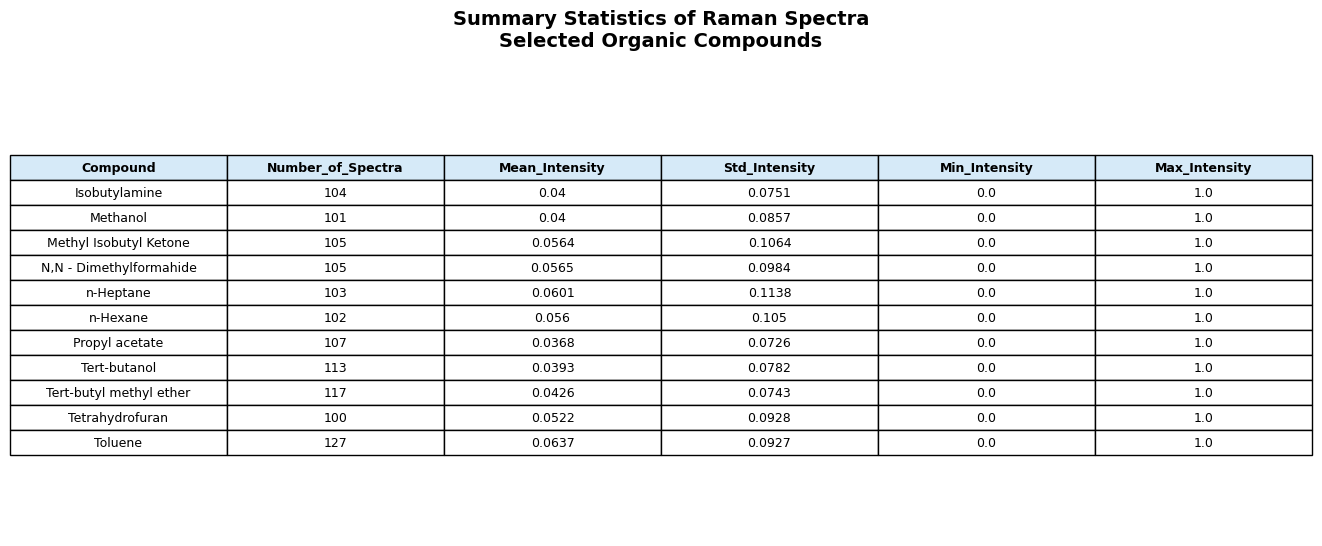


Files saved:
- summary_statistics_by_compound_selected.csv
- summary_statistics_by_compound_selected.xlsx
- summary_statistics_table_11_compounds.png


In [17]:
# ============================================================
# 6. DATA SUMMARIZATION
# Only the 11 selected compounds
# INCLUDING TABLE VISUALIZATION
# ============================================================

target_compounds = [
    "Isobutylamine",
    "Methanol",
    "Methyl Isobutyl Ketone",
    "N,N - Dimethylformahide",
    "n-Heptane",
    "n-Hexane",
    "Propyl acetate",
    "Tert-butanol",
    "Tert-butyl methyl ether",
    "Tetrahydrofuran",
    "Toluene"
]

# ============================================================
# CREATE PREPROCESSED DATAFRAME
# ============================================================

summary_df = pd.DataFrame(
    X_norm,
    columns=raman_cols
)

summary_df["Compound"] = y

# Keep only the 11 selected compounds
summary_df = summary_df[
    summary_df["Compound"].isin(target_compounds)
].copy()

print("\nCompounds included in summarization:")
print(summary_df["Compound"].value_counts())

print("\nNumber of compounds included:")
print(summary_df["Compound"].nunique())

# ============================================================
# OVERALL SUMMARY STATISTICS
# ============================================================

summary_stats = summary_df.drop(
    columns=["Compound"]
).describe()

summary_stats.to_csv(
    "raman_summary_statistics_selected_compounds.csv"
)

print("\nOverall summary statistics saved.")

# ============================================================
# SUMMARY STATISTICS BY COMPOUND
# ============================================================

compound_summary = []

for compound in target_compounds:

    subset = summary_df[
        summary_df["Compound"] == compound
    ].drop(columns=["Compound"])

    if subset.shape[0] > 0:

        compound_summary.append({

            "Compound": compound,

            "Number_of_Spectra": subset.shape[0],

            "Mean_Intensity":
                subset.values.mean(),

            "Std_Intensity":
                subset.values.std(),

            "Min_Intensity":
                subset.values.min(),

            "Max_Intensity":
                subset.values.max()
        })

compound_summary_df = pd.DataFrame(
    compound_summary
)

compound_summary_df = compound_summary_df.round(4)

# ============================================================
# DISPLAY SUMMARY TABLE
# ============================================================

print("\n================================================")
print("SUMMARY STATISTICS FOR THE 11 COMPOUNDS")
print("================================================")

print(compound_summary_df)

# ============================================================
# VISUALIZE TABLE AS FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.axis("off")

table = ax.table(
    cellText=compound_summary_df.values,
    colLabels=compound_summary_df.columns,
    cellLoc="center",
    loc="center"
)

# ------------------------------------------------------------
# FORMAT TABLE
# ------------------------------------------------------------

table.auto_set_font_size(False)

table.set_fontsize(9)

table.scale(1.2, 1.5)

# Header formatting
for (row, col), cell in table.get_celld().items():

    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor("#D6EAF8")

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

plt.title(
    "Summary Statistics of Raman Spectra\nSelected Organic Compounds",
    fontsize=14,
    weight="bold",
    pad=20
)

# ------------------------------------------------------------
# SAVE TABLE FIGURE
# ------------------------------------------------------------

plt.savefig(
    "summary_statistics_table_11_compounds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# SAVE TABLE FILES
# ============================================================

compound_summary_df.to_csv(
    "summary_statistics_by_compound_selected.csv",
    index=False
)

compound_summary_df.to_excel(
    "summary_statistics_by_compound_selected.xlsx",
    index=False
)

print("\nFiles saved:")
print("- summary_statistics_by_compound_selected.csv")
print("- summary_statistics_by_compound_selected.xlsx")
print("- summary_statistics_table_11_compounds.png")



A tabela mostra as estatisticas sumárias do expectro de Raman dos compostos organicos selecionados.

Significado das estatisticas na coluna:
Compound	Nome do composto orgânico
Number_of_Spectra	Número de espectros Raman desse composto
Mean_Intensity	Intensidade Raman média normalizada
Std_Intensity	Desvio padrão da intensidade espectral
Min_Intensity	Intensidade normalizada mínima (0 após MinMaxScaler)
Max_Intensity	Intensidade normalizada máxima (1 após MinMaxScaler)


Compounds included in plots:
Compound
Toluene                    127
Tert-butyl methyl ether    117
Tert-butanol               113
Propyl acetate             107
Methyl Isobutyl Ketone     105
N,N - Dimethylformahide    105
Isobutylamine              104
n-Heptane                  103
n-Hexane                   102
Methanol                   101
Tetrahydrofuran            100
Name: count, dtype: int64

Number of compounds included:
11


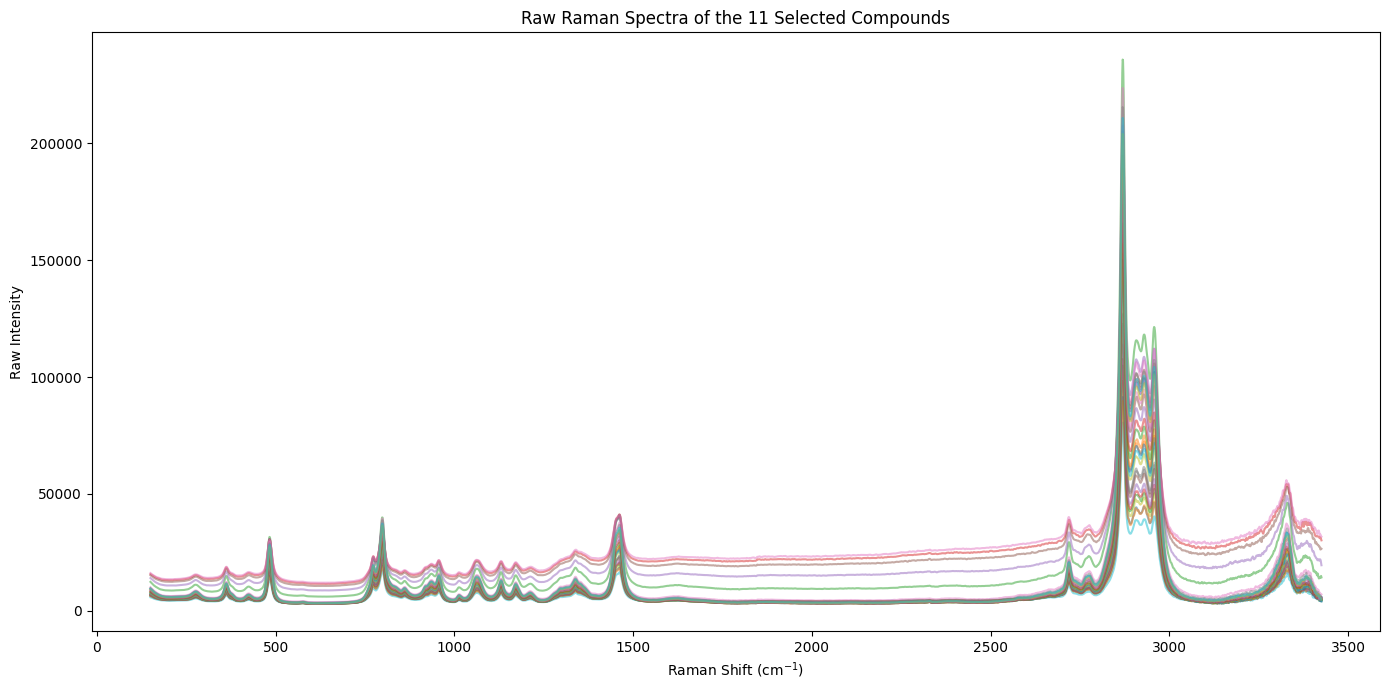

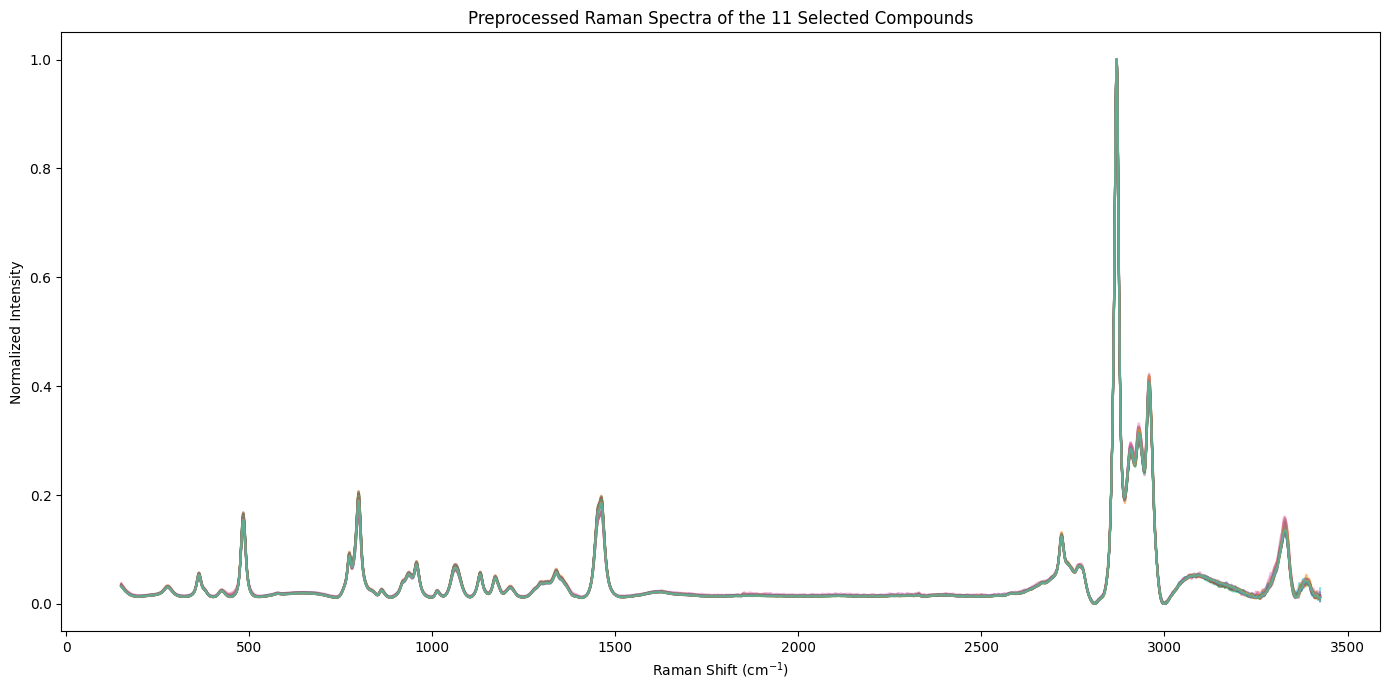

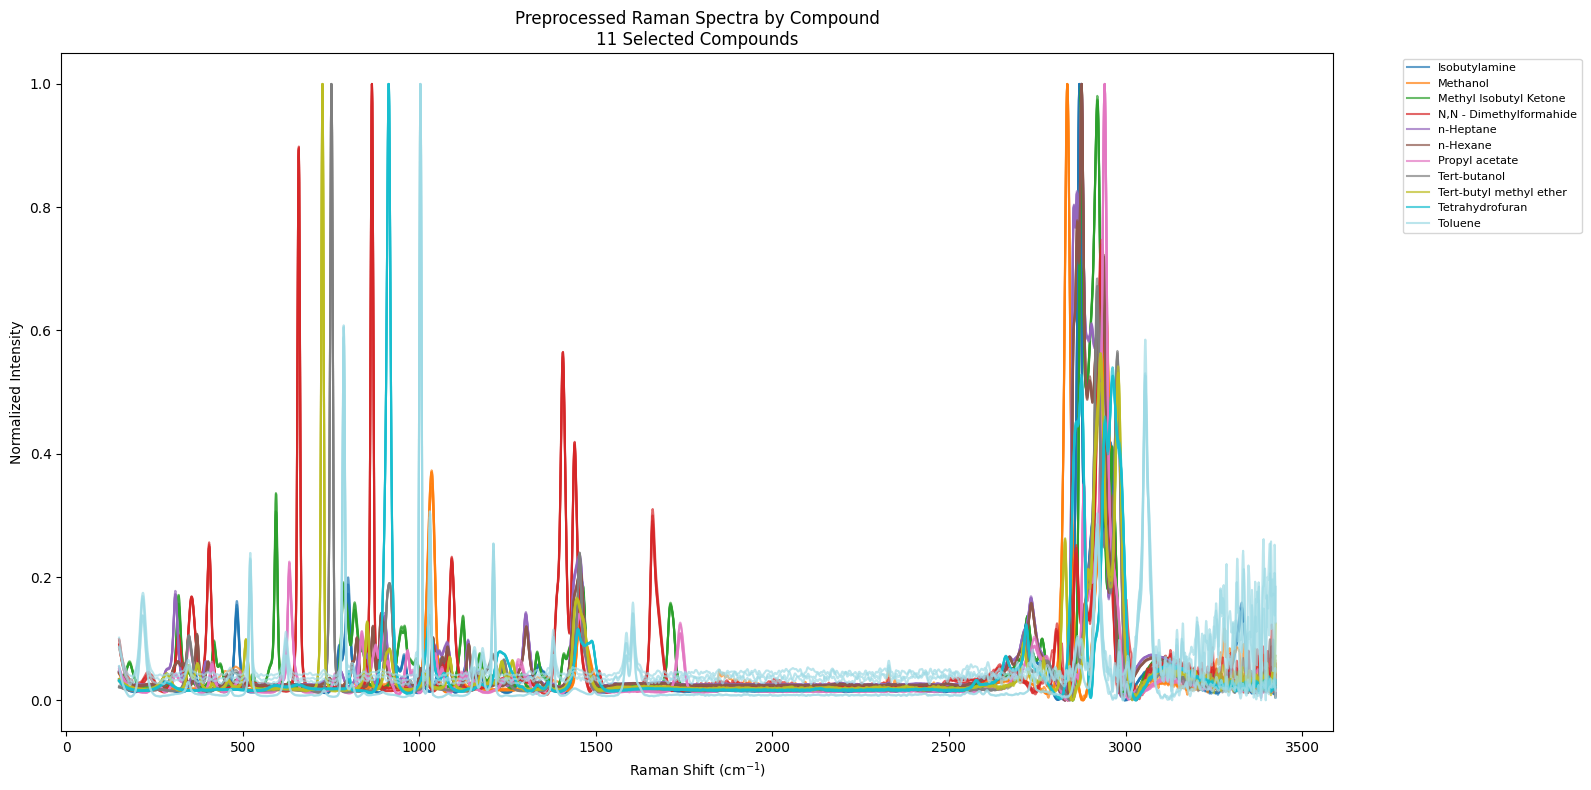

In [18]:
# ============================================================
# 7. GRAPHICAL EXPLORATION OF RAW AND PREPROCESSED SPECTRA
# Corrected to include all 11 selected compounds
# ============================================================

target_compounds = [
    "Isobutylamine",
    "Methanol",
    "Methyl Isobutyl Ketone",
    "N,N - Dimethylformahide",
    "n-Heptane",
    "n-Hexane",
    "Propyl acetate",
    "Tert-butanol",
    "Tert-butyl methyl ether",
    "Tetrahydrofuran",
    "Toluene"
]

label_col = "label"

# ============================================================
# IMPORTANT:
# Use df_filtered, X_raw, X_norm, y, raman_cols and raman_shifts
# created in the corrected preprocessing step
# ============================================================

plot_df = pd.DataFrame(
    X_norm,
    columns=raman_cols
)

plot_df["Compound"] = y

plot_df = plot_df[
    plot_df["Compound"].isin(target_compounds)
].copy()

print("\nCompounds included in plots:")
print(plot_df["Compound"].value_counts())

print("\nNumber of compounds included:")
print(plot_df["Compound"].nunique())

missing = set(target_compounds) - set(plot_df["Compound"].unique())

if len(missing) > 0:
    print("\nWARNING: These compounds are missing:")
    print(sorted(missing))

# ============================================================
# RAW DATA FOR THE SAME 11 COMPOUNDS
# ============================================================

df_raw_plot = df[
    df[label_col].isin(target_compounds)
].copy()

raman_cols_raw = [
    col for col in df_raw_plot.columns
    if col != label_col
]

X_raw_plot = df_raw_plot[raman_cols_raw].values
y_raw_plot = df_raw_plot[label_col].values

raman_shifts_raw = np.array([
    float(col)
    for col in raman_cols_raw
])

# ============================================================
# RAW RAMAN SPECTRA
# ============================================================

plt.figure(figsize=(14, 7))

n_spectra = min(30, X_raw_plot.shape[0])

for i in range(n_spectra):

    plt.plot(
        raman_shifts_raw,
        X_raw_plot[i],
        alpha=0.5
    )

plt.xlabel("Raman Shift (cm$^{-1}$)")
plt.ylabel("Raw Intensity")
plt.title("Raw Raman Spectra of the 11 Selected Compounds")

plt.tight_layout()

plt.savefig(
    "raw_raman_spectra_11_compounds.png",
    dpi=300
)

plt.show()

# ============================================================
# PREPROCESSED / NORMALIZED RAMAN SPECTRA
# ============================================================

X_norm_plot = plot_df[raman_cols].values
y_plot = plot_df["Compound"].values

plt.figure(figsize=(14, 7))

n_spectra = min(30, X_norm_plot.shape[0])

for i in range(n_spectra):

    plt.plot(
        raman_shifts,
        X_norm_plot[i],
        alpha=0.5
    )

plt.xlabel("Raman Shift (cm$^{-1}$)")
plt.ylabel("Normalized Intensity")
plt.title("Preprocessed Raman Spectra of the 11 Selected Compounds")

plt.tight_layout()

plt.savefig(
    "preprocessed_raman_spectra_11_compounds.png",
    dpi=300
)

plt.show()

# ============================================================
# COLORED PREPROCESSED PLOTS BY COMPOUND
# ============================================================

unique_compounds = np.array(target_compounds)

colors = plt.cm.tab20(
    np.linspace(0, 1, len(unique_compounds))
)

plt.figure(figsize=(16, 8))

for compound, color in zip(unique_compounds, colors):

    idx = np.where(y_plot == compound)[0]

    idx = idx[:5]

    for j, i in enumerate(idx):

        plt.plot(
            raman_shifts,
            X_norm_plot[i],
            color=color,
            alpha=0.7,
            label=compound if j == 0 else ""
        )

plt.xlabel("Raman Shift (cm$^{-1}$)")
plt.ylabel("Normalized Intensity")

plt.title(
    "Preprocessed Raman Spectra by Compound\n11 Selected Compounds"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "preprocessed_raman_spectra_by_compound_11_compounds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Estes gráficos mostram os espectros Raman dos 11 compostos orgânicos selecionados antes e depois do pré-processamento, separados por composto e representados com cores diferentes.

Os gráficos utiliza os espectros suavizados, corrigidos da linha de base (“baseline correction”) e normalizados entre 0 e 1. Cada linha do gráfico corresponde a um espectro Raman individual.

Estes gráficos permitem comparar visualmente os compostos e identificar diferenças entre perfis espectrais, observar bandas Raman características, verificar variabilidade entre espectros do mesmo composto e avaliar se os compostos apresentam padrões distintos. Picos em regiões diferentes indicam potenciais diferenças em ligações químicas, grupos funcionais e estruturas moleculares. 

5. comparação visual dos espectros médios dos compostos e identificação de bandas
Raman relevantes;


Compounds included:
Compound
Toluene                    127
Tert-butyl methyl ether    117
Tert-butanol               113
Propyl acetate             107
Methyl Isobutyl Ketone     105
N,N - Dimethylformahide    105
Isobutylamine              104
n-Heptane                  103
n-Hexane                   102
Methanol                   101
Tetrahydrofuran            100
Name: count, dtype: int64

Number of compounds included:
11

Mean spectra saved:
mean_spectra_11_selected_compounds.csv


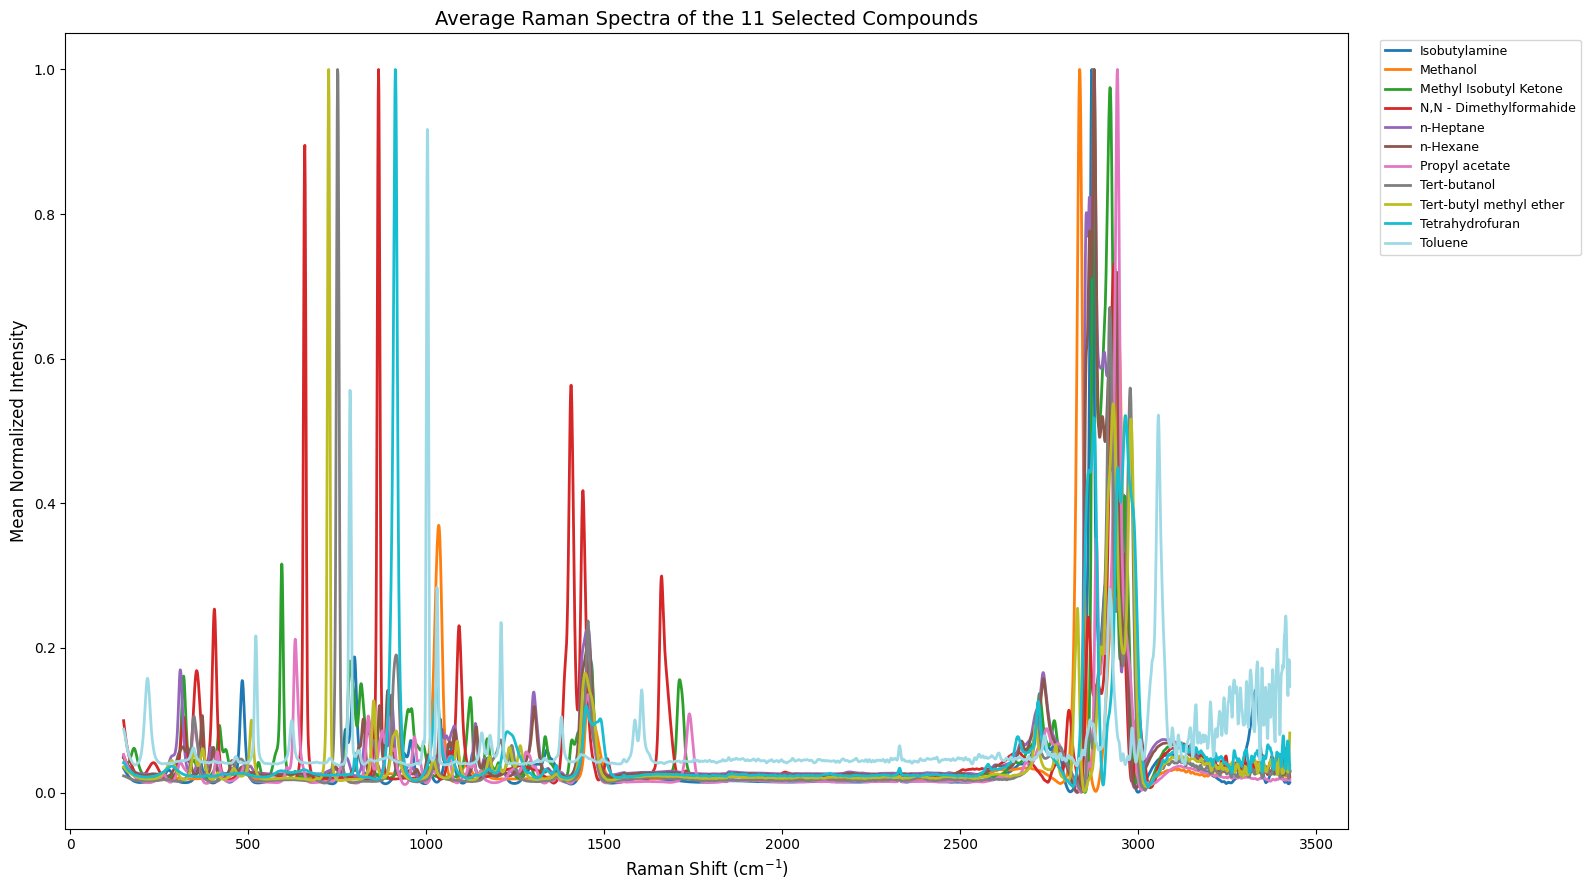

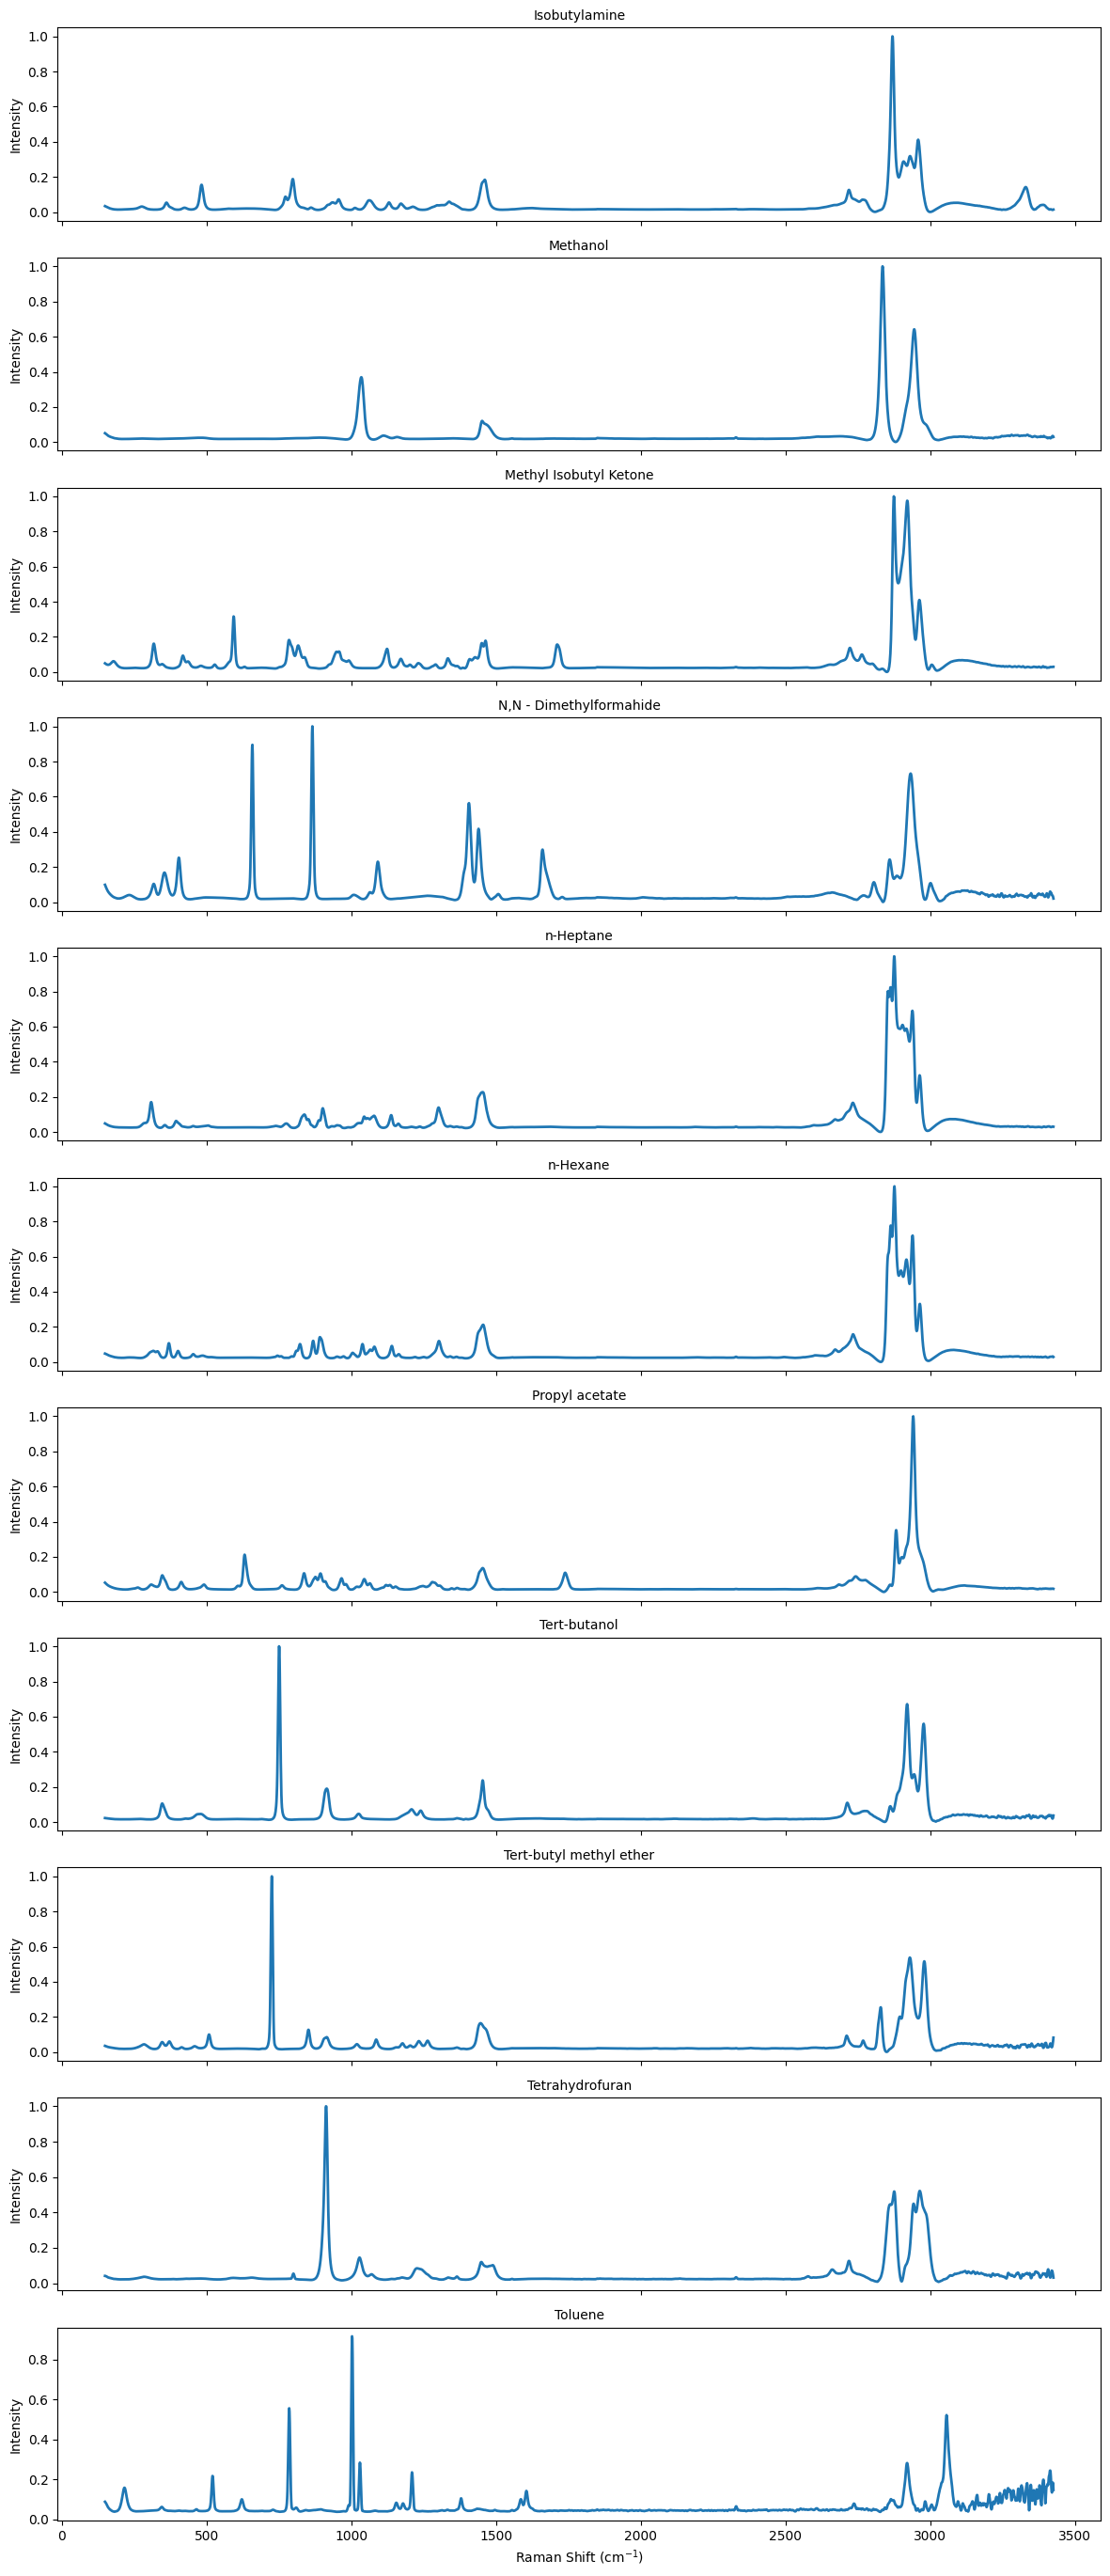

In [19]:
# ============================================================
# 8. AVERAGE SPECTRA PER COMPOUND
# Corrected to include all 11 selected compounds
# ============================================================

target_compounds = [
    "Isobutylamine",
    "Methanol",
    "Methyl Isobutyl Ketone",
    "N,N - Dimethylformahide",
    "n-Heptane",
    "n-Hexane",
    "Propyl acetate",
    "Tert-butanol",
    "Tert-butyl methyl ether",
    "Tetrahydrofuran",
    "Toluene"
]

# ============================================================
# CREATE PREPROCESSED DATAFRAME
# Use X_norm and y from the corrected preprocessing step
# ============================================================

df_preprocessed = pd.DataFrame(
    X_norm,
    columns=raman_cols
)

df_preprocessed["Compound"] = y

# Keep only the 11 selected compounds
df_preprocessed = df_preprocessed[
    df_preprocessed["Compound"].isin(target_compounds)
].copy()

print("\nCompounds included:")
print(df_preprocessed["Compound"].value_counts())

print("\nNumber of compounds included:")
print(df_preprocessed["Compound"].nunique())

missing = set(target_compounds) - set(df_preprocessed["Compound"].unique())

if len(missing) > 0:
    print("\nWARNING: These compounds are missing:")
    print(sorted(missing))

# ============================================================
# CALCULATE MEAN SPECTRA
# ============================================================

mean_spectra = df_preprocessed.groupby(
    "Compound"
)[raman_cols].mean()

# Reorder rows according to target_compounds
mean_spectra = mean_spectra.loc[
    [c for c in target_compounds if c in mean_spectra.index]
]

mean_spectra.to_csv(
    "mean_spectra_11_selected_compounds.csv"
)

print("\nMean spectra saved:")
print("mean_spectra_11_selected_compounds.csv")

# ============================================================
# PLOT AVERAGE SPECTRA
# ============================================================

plt.figure(figsize=(16, 9))

colors = plt.cm.tab20(
    np.linspace(0, 1, len(mean_spectra.index))
)

for compound, color in zip(mean_spectra.index, colors):

    plt.plot(
        raman_shifts,
        mean_spectra.loc[compound],
        linewidth=2,
        label=compound,
        color=color
    )

plt.xlabel("Raman Shift (cm$^{-1}$)", fontsize=12)
plt.ylabel("Mean Normalized Intensity", fontsize=12)

plt.title(
    "Average Raman Spectra of the 11 Selected Compounds",
    fontsize=14
)

plt.legend(
    fontsize=9,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "average_spectra_11_selected_compounds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# INDIVIDUAL MEAN SPECTRA SUBPLOTS
# ============================================================

n_compounds = len(mean_spectra.index)

fig, axes = plt.subplots(
    nrows=n_compounds,
    ncols=1,
    figsize=(12, 2.5 * n_compounds),
    sharex=True
)

if n_compounds == 1:
    axes = [axes]

for ax, compound in zip(axes, mean_spectra.index):

    ax.plot(
        raman_shifts,
        mean_spectra.loc[compound],
        linewidth=2
    )

    ax.set_title(compound, fontsize=10)
    ax.set_ylabel("Intensity")

axes[-1].set_xlabel("Raman Shift (cm$^{-1}$)")

plt.tight_layout()

plt.savefig(
    "individual_average_spectra_11_selected_compounds.png",
    dpi=300
)

plt.show()

Nesta etapa, o código calcula um espectro Raman representativo para cada composto orgânico, obtido a partir da média de todos os espectros desse composto. Para cada composto todos os espectros Raman foram agrupados, a intensidade média foi calculada em cada variável Raman Shift e o resultado final é o espectro médio para cada composto representando o perfil Raman típico desse composto.

Os gráficos “Average Raman Spectra” para os 11 compostos e para cada composto mostra uma linha por composto e cada linha mostra a intensidade média ao longo do espectro Raman. Permite identificar bandas Raman características, grupos funcionais e assinaturas espectrais específicas.


Compounds included in Raman band analysis:
['Isobutylamine', 'Methanol', 'Methyl Isobutyl Ketone', 'N,N - Dimethylformahide', 'n-Heptane', 'n-Hexane', 'Propyl acetate', 'Tert-butanol', 'Tert-butyl methyl ether', 'Tetrahydrofuran', 'Toluene']

Number of compounds included:
11

Top 30 most variable Raman shifts:
2874.0    0.176092
2875.0    0.174391
2873.0    0.171674
2876.0    0.165624
2872.0    0.163073
2871.0    0.152326
2877.0    0.150519
2870.0    0.140996
2878.0    0.131396
2869.0    0.130091
2868.0    0.120306
2867.0    0.112188
2879.0    0.111270
2866.0    0.106038
2865.0    0.101658
2864.0    0.098267
2863.0    0.094794
2880.0    0.092707
2862.0    0.090421
726.0     0.086870
2835.0    0.086687
751.0     0.086460
2836.0    0.085386
752.0     0.085148
2861.0    0.085033
2834.0    0.084774
866.0     0.084740
914.0     0.083275
913.0     0.083258
2837.0    0.080944
dtype: float64

Top discriminative Raman bands:
    Raman_Shift_cm-1  Variance        Tentative_Assignment
0         

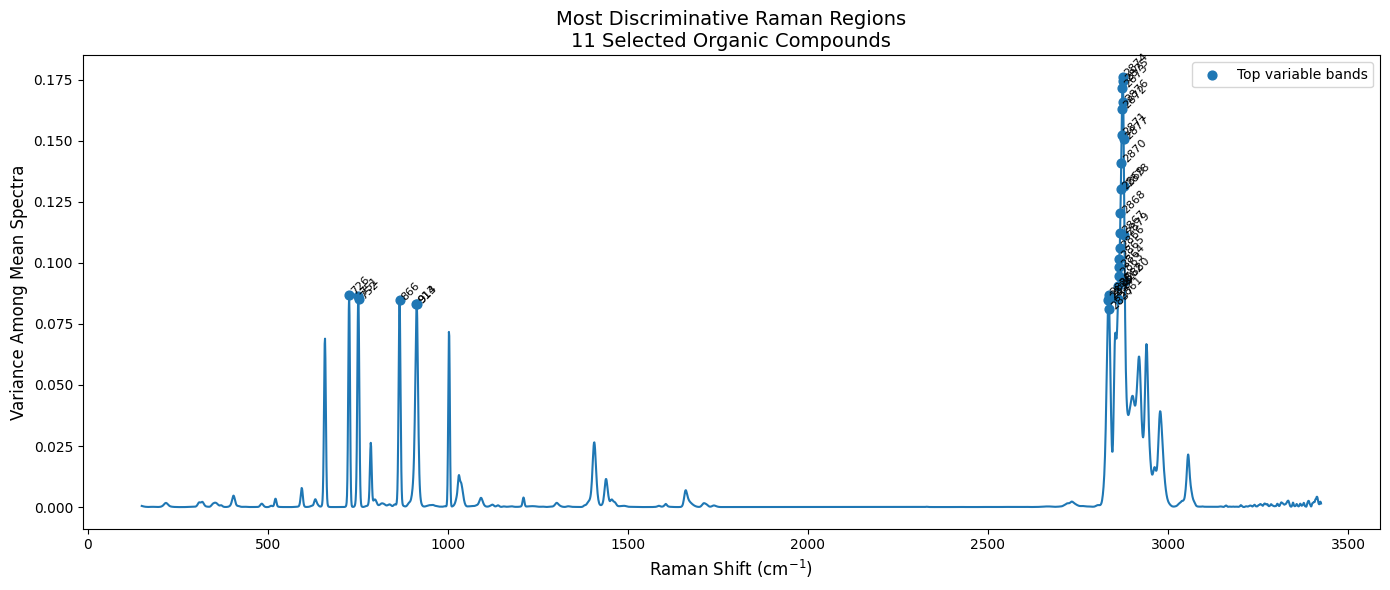


Files saved:
- most_variable_raman_bands_11_compounds.csv
- top_discriminative_raman_bands_11_compounds.csv
- top_discriminative_raman_bands_11_compounds.xlsx
- variable_raman_regions_11_compounds.png


In [20]:
# ============================================================
# 9. IDENTIFICATION OF RELEVANT RAMAN BANDS
# Corrected to include all 11 selected compounds
# Using variance across compound mean spectra
# ============================================================

target_compounds = [
    "Isobutylamine",
    "Methanol",
    "Methyl Isobutyl Ketone",
    "N,N - Dimethylformahide",
    "n-Heptane",
    "n-Hexane",
    "Propyl acetate",
    "Tert-butanol",
    "Tert-butyl methyl ether",
    "Tetrahydrofuran",
    "Toluene"
]

# ============================================================
# FILTER MEAN SPECTRA TO THE 11 COMPOUNDS
# ============================================================

mean_spectra_filtered = mean_spectra.loc[
    [c for c in target_compounds if c in mean_spectra.index]
]

print("\nCompounds included in Raman band analysis:")
print(mean_spectra_filtered.index.tolist())

print("\nNumber of compounds included:")
print(len(mean_spectra_filtered.index))

missing = set(target_compounds) - set(mean_spectra_filtered.index)

if len(missing) > 0:
    print("\nWARNING: These compounds are missing:")
    print(sorted(missing))

# ============================================================
# CALCULATE VARIANCE ACROSS COMPOUNDS
# ============================================================

band_variance = mean_spectra_filtered.var(axis=0)

top_bands = band_variance.sort_values(
    ascending=False
).head(30)

print("\nTop 30 most variable Raman shifts:")
print(top_bands)

top_bands.to_csv(
    "most_variable_raman_bands_11_compounds.csv"
)

# ============================================================
# CONVERT TO DATAFRAME
# ============================================================

top_bands_df = pd.DataFrame({
    "Raman_Shift_cm-1": top_bands.index.astype(float),
    "Variance": top_bands.values
})

top_bands_df = top_bands_df.sort_values(
    by="Variance",
    ascending=False
)

# ============================================================
# TENTATIVE RAMAN REGION ASSIGNMENT
# ============================================================

def assign_raman_region(shift):

    shift = float(shift)

    if 2800 <= shift <= 3100:
        return "C-H stretching region"

    elif 1700 <= shift <= 1750:
        return "C=O stretching region"

    elif 1600 <= shift < 1700:
        return "Aromatic C=C / C=O region"

    elif 1200 <= shift < 1600:
        return "Fingerprint region"

    elif 900 <= shift < 1200:
        return "C-C / C-O / C-N vibrations"

    elif 600 <= shift < 900:
        return "Ring / skeletal vibrations"

    else:
        return "Other compound-specific region"


top_bands_df["Tentative_Assignment"] = (
    top_bands_df["Raman_Shift_cm-1"]
    .apply(assign_raman_region)
)

print("\nTop discriminative Raman bands:")
print(top_bands_df)

top_bands_df.to_csv(
    "top_discriminative_raman_bands_11_compounds.csv",
    index=False
)

top_bands_df.to_excel(
    "top_discriminative_raman_bands_11_compounds.xlsx",
    index=False
)

# ============================================================
# PLOT VARIANCE ACROSS RAMAN SHIFTS
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    raman_shifts,
    band_variance.values,
    linewidth=1.5
)

plt.scatter(
    top_bands.index.astype(float),
    top_bands.values,
    s=40,
    label="Top variable bands"
)

for shift, variance in zip(
    top_bands.index.astype(float),
    top_bands.values
):

    plt.text(
        shift,
        variance,
        f"{int(shift)}",
        fontsize=8,
        rotation=45
    )

plt.xlabel("Raman Shift (cm$^{-1}$)", fontsize=12)
plt.ylabel("Variance Among Mean Spectra", fontsize=12)

plt.title(
    "Most Discriminative Raman Regions\n11 Selected Organic Compounds",
    fontsize=14
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "variable_raman_regions_11_compounds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFiles saved:")
print("- most_variable_raman_bands_11_compounds.csv")
print("- top_discriminative_raman_bands_11_compounds.csv")
print("- top_discriminative_raman_bands_11_compounds.xlsx")
print("- variable_raman_regions_11_compounds.png")

Nesta etapa, o código identifica os Raman Shift com maior variabilidade entre os 11 compostos. Os resultados da análise de bandas Raman discriminativas foram guardados com sucesso em quatro ficheiros diferentes.

Files saved:
- most_variable_raman_bands_11_compounds.csv -  
Contém os Raman Shift com maior variabilidade entre os 11 compostos.
Estas regiões são potencialmente importantes para distinguir compostos.

- top_discriminative_raman_bands_11_compounds.csv

Tabela formatada contendo o mesmo tipo de informação mas numa versão mais organizada para análise estatística.


- top_discriminative_raman_bands_11_compounds.xlsx
A mesma tabela anterior, mas em formato Excel.


- variable_raman_regions_11_compounds.png

Figura/gráfico que mostra a variância ao longo do espectro Raman, indicando as regiões mais importantes para discriminar compostos. No gráfico, o  eixo X mostra o Raman Shift (cm⁻¹) e o
eixo Y mostra a variância entre compostos.

Os picos mais altos representam regiões espectrais mais informativas.


6. análise estatística multivariada não supervisionada, incluindo redução de
dimensionalidade/visualização, por exemplo PCA, t-SNE ou UMAP;


Compounds included in PCA:
Compound
Toluene                    127
Tert-butyl methyl ether    117
Tert-butanol               113
Propyl acetate             107
Methyl Isobutyl Ketone     105
N,N - Dimethylformahide    105
Isobutylamine              104
n-Heptane                  103
n-Hexane                   102
Methanol                   101
Tetrahydrofuran            100
Name: count, dtype: int64

Number of compounds included:
11

All 11 compounds included in PCA.

Explained variance by first PCs:
[0.64062599 0.07518325 0.06981757 0.04871148 0.03661021]


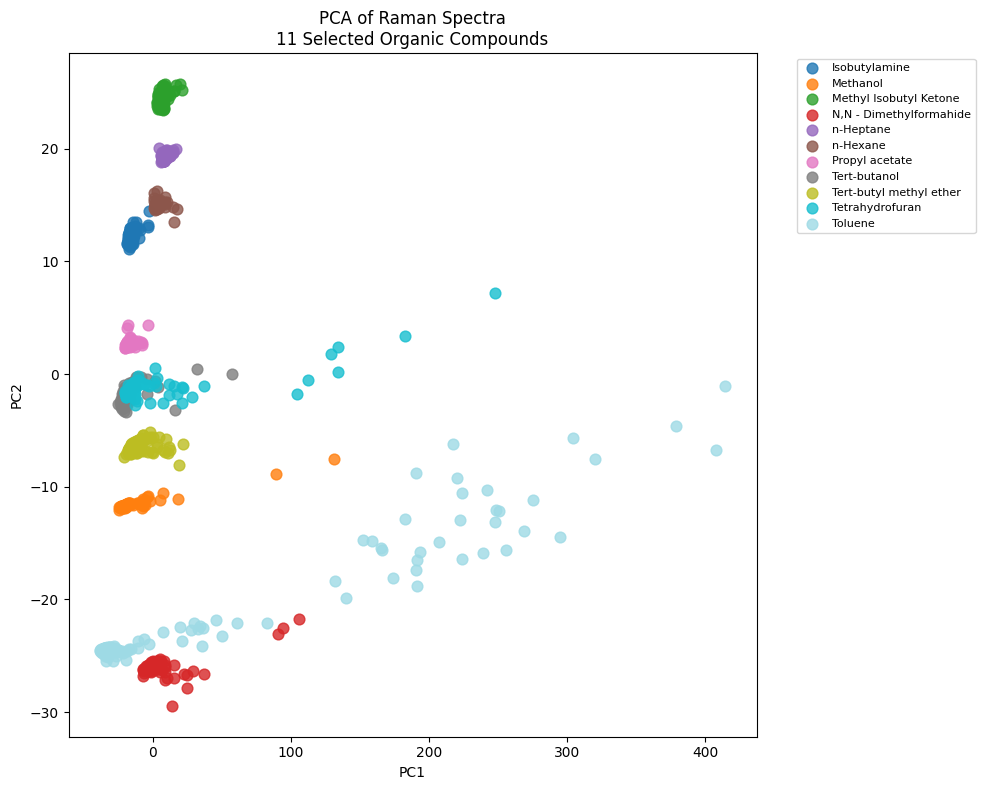


Important Raman shifts contributing to PC1:
      Raman_shift  PC1_loading
412         562.0     0.021734
413         563.0     0.021732
411         561.0     0.021730
410         560.0     0.021721
414         564.0     0.021721
409         559.0     0.021711
1759       1909.0     0.021702
408         558.0     0.021701
1760       1910.0     0.021698
415         565.0     0.021698
1758       1908.0     0.021696
1679       1829.0     0.021695
1680       1830.0     0.021695
1846       1996.0     0.021694
2171       2321.0     0.021694
1847       1997.0     0.021693
407         557.0     0.021692
1848       1998.0     0.021691
2194       2344.0     0.021691
1678       1828.0     0.021690
1681       1831.0     0.021690
2170       2320.0     0.021690
1694       1844.0     0.021690
1410       1560.0     0.021690
1845       1995.0     0.021689
1849       1999.0     0.021689
529         679.0     0.021689
388         538.0     0.021688
1685       1835.0     0.021688
1761       1911.0     0.0

In [21]:
# ============================================================
# 10. PCA ANALYSIS
# Corrected to include all 11 selected compounds
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

target_compounds = [
    "Isobutylamine",
    "Methanol",
    "Methyl Isobutyl Ketone",
    "N,N - Dimethylformahide",
    "n-Heptane",
    "n-Hexane",
    "Propyl acetate",
    "Tert-butanol",
    "Tert-butyl methyl ether",
    "Tetrahydrofuran",
    "Toluene"
]

# ============================================================
# CREATE PCA INPUT DATAFRAME
# Uses X_norm and y from corrected Section 5
# ============================================================

pca_input_df = pd.DataFrame(
    X_norm,
    columns=raman_cols
)

pca_input_df["Compound"] = y

# Keep only the 11 selected compounds
pca_input_df = pca_input_df[
    pca_input_df["Compound"].isin(target_compounds)
].copy()

print("\nCompounds included in PCA:")
print(pca_input_df["Compound"].value_counts())

print("\nNumber of compounds included:")
print(pca_input_df["Compound"].nunique())

missing = set(target_compounds) - set(pca_input_df["Compound"].unique())

if len(missing) > 0:
    print("\nWARNING: These compounds are missing:")
    print(sorted(missing))
else:
    print("\nAll 11 compounds included in PCA.")

# ============================================================
# EXTRACT FEATURES AND LABELS
# ============================================================

X_pca_input = pca_input_df[raman_cols].values
y_pca = pca_input_df["Compound"].values

# Standardize Raman intensities
X_scaled = StandardScaler().fit_transform(X_pca_input)

# ============================================================
# RUN PCA
# ============================================================

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Compound": y_pca
})

print("\nExplained variance by first PCs:")
print(pca.explained_variance_ratio_[:5])

# ============================================================
# PLOT PCA
# ============================================================

plt.figure(figsize=(10, 8))

colors = plt.cm.tab20(
    np.linspace(0, 1, len(target_compounds))
)

for compound, color in zip(target_compounds, colors):

    subset = pca_df[
        pca_df["Compound"] == compound
    ]

    if subset.shape[0] > 0:
        plt.scatter(
            subset["PC1"],
            subset["PC2"],
            label=compound,
            s=60,
            alpha=0.8,
            color=color
        )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "PCA of Raman Spectra\n11 Selected Organic Compounds"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "pca_raman_spectra_11_compounds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# SAVE PCA SCORES
# ============================================================

pca_df.to_csv(
    "pca_scores_11_compounds.csv",
    index=False
)

# ============================================================
# PCA LOADINGS: IMPORTANT RAMAN SHIFTS
# ============================================================

loadings = pd.DataFrame({
    "Raman_shift": raman_shifts,
    "PC1_loading": pca.components_[0],
    "PC2_loading": pca.components_[1]
})

loadings["PC1_abs"] = loadings["PC1_loading"].abs()
loadings["PC2_abs"] = loadings["PC2_loading"].abs()

important_pc1_bands = loadings.sort_values(
    "PC1_abs",
    ascending=False
).head(30)

important_pc2_bands = loadings.sort_values(
    "PC2_abs",
    ascending=False
).head(30)

print("\nImportant Raman shifts contributing to PC1:")
print(important_pc1_bands[["Raman_shift", "PC1_loading"]])

print("\nImportant Raman shifts contributing to PC2:")
print(important_pc2_bands[["Raman_shift", "PC2_loading"]])

important_pc1_bands.to_csv(
    "important_pc1_bands_11_compounds.csv",
    index=False
)

important_pc2_bands.to_csv(
    "important_pc2_bands_11_compounds.csv",
    index=False
)

print("\nFiles saved:")
print("- pca_raman_spectra_11_compounds.png")
print("- pca_scores_11_compounds.csv")
print("- important_pc1_bands_11_compounds.csv")
print("- important_pc2_bands_11_compounds.csv")

Foi realizada uma analise de Principal Components (PCA) que mostra a proporção da variância total dos espectros Raman explicada pelos primeiros Componentes Principais (PCs) da análise PCA.

O primeiro componente (PC1) explica a maior parte da variação dos espectros Raman (64%). Isto sugere que existe uma forte estrutura nos dados e que muitos compostos diferem principalmente ao longo deste eixo. Em espectroscopia Raman, isto pode indicar diferenças fortes na composição química, presença/ausência de grupos funcionais e diferenças na intensidade de bandas principais. Os primeiros cinco componentes principais explicaram conjuntamente cerca de 87% da variância total, sugerindo que a maior parte da informação espectral foi capturada num espaço dimensional reduzido.

No gráfico do PCA é possível verificar que a maoria dos compostos são diferentes entre si muito embora, alguns os compostos estejam agrupados, sugerindo que tenham perfis quimícos semelhantes (por exemplo, o Methyl Isobutyl Ketone, n-Heptane, n-Hexane e o Isobutylamine). Alguns compostos sobrepõem-se no gráfico do PCA, tais como o Tetrahydrofuran e o Tert-butanol, sugerindo o mesmo perfis químicos ou possível similaridade estrutural/química. 

Compostos como o N,N - Dimethylformahide e sobretudo o Toluene apresentam elevada variabilidade interna, o que sugere que os espectros desse composto não são muito semelhantes entre si. Talvez exista nestes compostos diversidade criptica. O composto pode apresentar diferentes conformações moleculares, impurezas, diferentes estados físicos, variação de concentração e
interações intermoleculares. A dispersão pode resultar de ruído instrumental, baixa qualidade do sinal, fluorescência, problemas de aquisição e variação na preparação da amostra. 


Para verificar se a elevada dispersão se deve à presença de outliers:

(array([310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322,
        323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335,
        336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348,
        349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361,
        362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374,
        375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387,
        388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400,
        401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413,
        414]),)

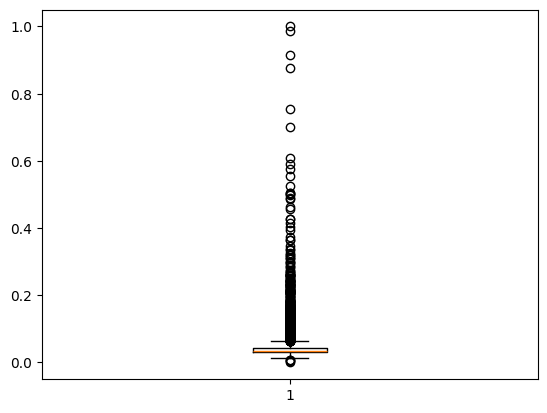

In [23]:
plt.boxplot(X_norm[i])
np.where(y == "N,N - Dimethylformahide")

(array([1057, 1058, 1059, 1060, 1061, 1062, 1063, 1064, 1065, 1066, 1067,
        1068, 1069, 1070, 1071, 1072, 1073, 1074, 1075, 1076, 1077, 1078,
        1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087, 1088, 1089,
        1090, 1091, 1092, 1093, 1094, 1095, 1096, 1097, 1098, 1099, 1100,
        1101, 1102, 1103, 1104, 1105, 1106, 1107, 1108, 1109, 1110, 1111,
        1112, 1113, 1114, 1115, 1116, 1117, 1118, 1119, 1120, 1121, 1122,
        1123, 1124, 1125, 1126, 1127, 1128, 1129, 1130, 1131, 1132, 1133,
        1134, 1135, 1136, 1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144,
        1145, 1146, 1147, 1148, 1149, 1150, 1151, 1152, 1153, 1154, 1155,
        1156, 1157, 1158, 1159, 1160, 1161, 1162, 1163, 1164, 1165, 1166,
        1167, 1168, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176, 1177,
        1178, 1179, 1180, 1181, 1182, 1183]),)

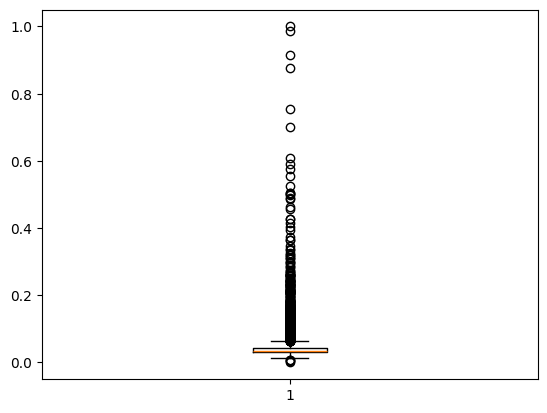

In [24]:
plt.boxplot(X_norm[i])
np.where(y == "Toluene")

In [ ]:
Não parece haver uma grande quantidade de espectros anómalos.


Compounds included in t-SNE:
Compound
Toluene                    127
Tert-butyl methyl ether    117
Tert-butanol               113
Propyl acetate             107
Methyl Isobutyl Ketone     105
N,N - Dimethylformahide    105
Isobutylamine              104
n-Heptane                  103
n-Hexane                   102
Methanol                   101
Tetrahydrofuran            100
Name: count, dtype: int64

Number of compounds included:
11


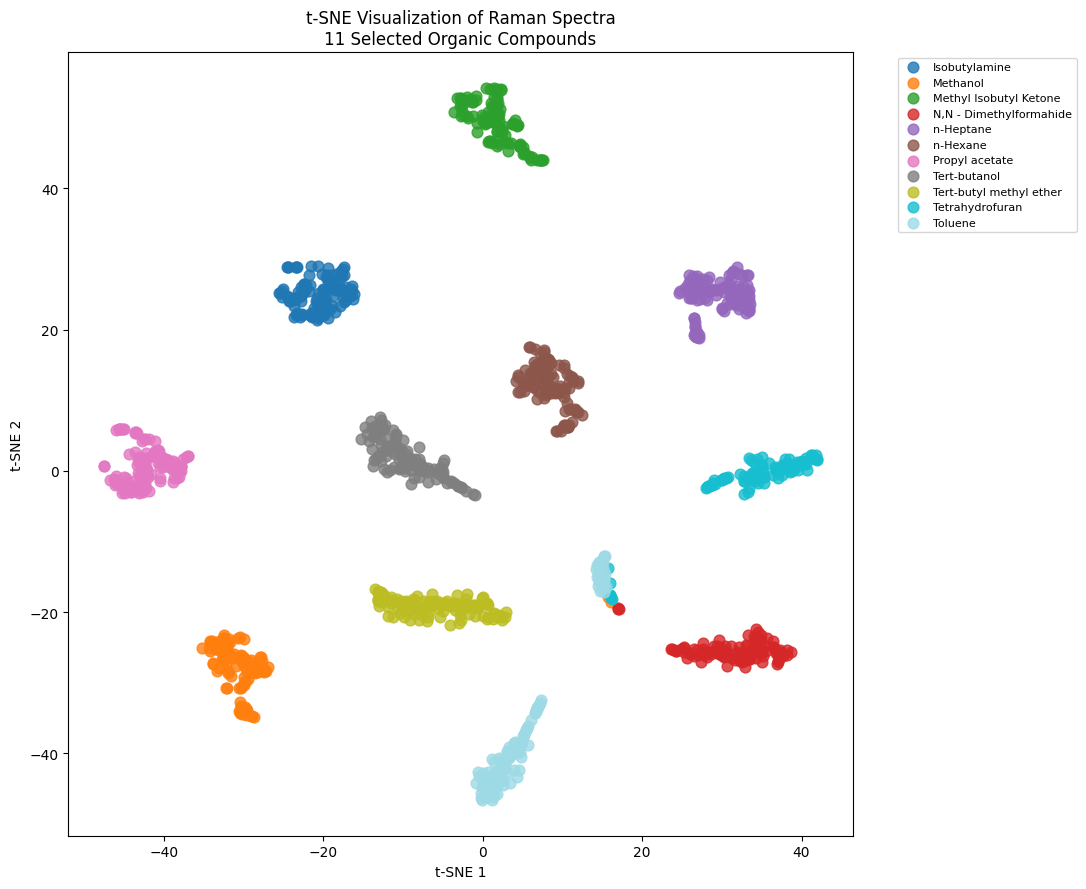


Files saved:
- tsne_coordinates_11_compounds.csv
- tsne_raman_spectra_11_compounds.png


In [22]:
# ============================================================
# 11. t-SNE VISUALIZATION
# Corrected to include all 11 selected compounds
# ============================================================

target_compounds = [
    "Isobutylamine",
    "Methanol",
    "Methyl Isobutyl Ketone",
    "N,N - Dimethylformahide",
    "n-Heptane",
    "n-Hexane",
    "Propyl acetate",
    "Tert-butanol",
    "Tert-butyl methyl ether",
    "Tetrahydrofuran",
    "Toluene"
]

# ============================================================
# CREATE DATAFRAME WITH PREPROCESSED DATA
# Use X_norm and y from corrected preprocessing step
# ============================================================

tsne_input_df = pd.DataFrame(
    X_norm,
    columns=raman_cols
)

tsne_input_df["Compound"] = y

tsne_input_df = tsne_input_df[
    tsne_input_df["Compound"].isin(target_compounds)
].copy()

print("\nCompounds included in t-SNE:")
print(tsne_input_df["Compound"].value_counts())

print("\nNumber of compounds included:")
print(tsne_input_df["Compound"].nunique())

missing = set(target_compounds) - set(tsne_input_df["Compound"].unique())

if len(missing) > 0:
    print("\nWARNING: These compounds are missing:")
    print(sorted(missing))

# ============================================================
# EXTRACT FEATURES AND LABELS
# ============================================================

X_tsne_input = tsne_input_df[raman_cols].values
y_tsne = tsne_input_df["Compound"].values

# ============================================================
# STANDARDIZE DATA
# ============================================================

X_scaled_tsne = StandardScaler().fit_transform(
    X_tsne_input
)

# ============================================================
# RUN t-SNE
# ============================================================

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(
    X_scaled_tsne
)

# ============================================================
# CREATE RESULTS DATAFRAME
# ============================================================

tsne_df = pd.DataFrame({
    "tSNE1": X_tsne[:, 0],
    "tSNE2": X_tsne[:, 1],
    "Compound": y_tsne
})

tsne_df.to_csv(
    "tsne_coordinates_11_compounds.csv",
    index=False
)

# ============================================================
# PLOT t-SNE
# ============================================================

plt.figure(figsize=(11, 9))

colors = plt.cm.tab20(
    np.linspace(0, 1, len(target_compounds))
)

for compound, color in zip(target_compounds, colors):

    subset = tsne_df[
        tsne_df["Compound"] == compound
    ]

    if subset.shape[0] > 0:

        plt.scatter(
            subset["tSNE1"],
            subset["tSNE2"],
            label=compound,
            s=60,
            alpha=0.8,
            color=color
        )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.title(
    "t-SNE Visualization of Raman Spectra\n11 Selected Organic Compounds"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "tsne_raman_spectra_11_compounds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFiles saved:")
print("- tsne_coordinates_11_compounds.csv")
print("- tsne_raman_spectra_11_compounds.png")


Foi realizada um t-distributed Stochastic Neighbor Embedding (t-SNE) cujo objectivo é verificar se os espectros Raman dos compostos formam grupos naturais e possuem padrões químicos distinguíveis.

É uma analise semelhante ao PCA mas tem algumas diferenças

Diferença entre PCA e t-SNE
PCA	                                t-SNE
Método linear	                    Método não linear
Preserva variância global	        Preserva vizinhanças locais
Mais interpretável	                Melhor visualização de clusters
Componentes principais	            Embedding visual

O t-SNE geralmente mostra separação de grupos melhor do que PCA em dados Raman complexos.

No caso da analise, o PCA e o t-SNE mostram padrões semelhantes (a maoria dos compostos são diferentes entre si) muito embora, alguns os compostos estejam sobrepostos - Methanol, Toluene, N,N - Dimethylformahide e o Tetrahydrofuran. A sobreposição parcial no espaço t-SNE sugere similaridade espectral entre os seus perfis Raman, o pode refletir a presença de bandas Raman semelhantes, intensidades relativas parecidas e padrões vibracionais parcialmente comuns, sugerindo presença de grupos funcionais semelhantes, similaridade espectral na região fingerprint e compostos com maior dispersão espectral.

7. análise preditiva/aprendizagem máquina, por exemplo classificação do composto, da
família química ou de uma propriedade molecular, comparando o desempenho de vários
modelos;


Compounds included in clustering:
Compound
Toluene                    127
Tert-butyl methyl ether    117
Tert-butanol               113
Propyl acetate             107
Methyl Isobutyl Ketone     105
N,N - Dimethylformahide    105
Isobutylamine              104
n-Heptane                  103
n-Hexane                   102
Methanol                   101
Tetrahydrofuran            100
Name: count, dtype: int64

Number of compounds included:
11

Cluster composition:
Compound  Isobutylamine  Methanol  Methyl Isobutyl Ketone  \
Cluster                                                     
0                     0        96                       0   
1                     0         0                       0   
2                     0         0                       0   
3                     0         0                       0   
4                     0         2                       0   
5                     0         0                       0   
6                     0         0            

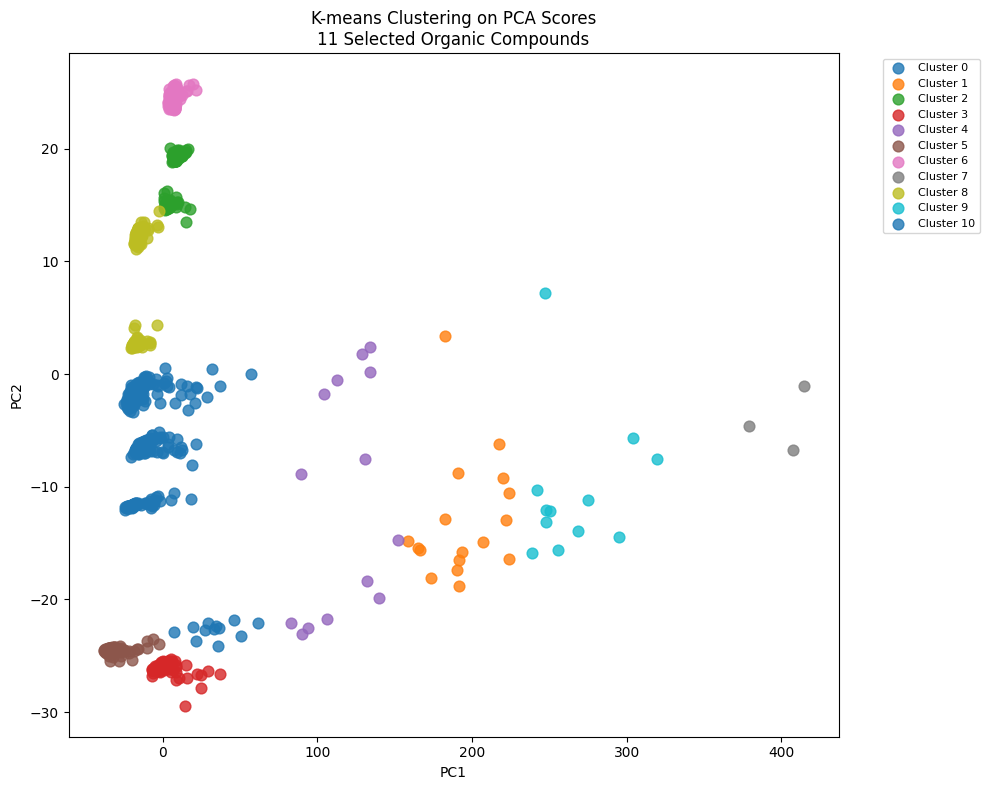

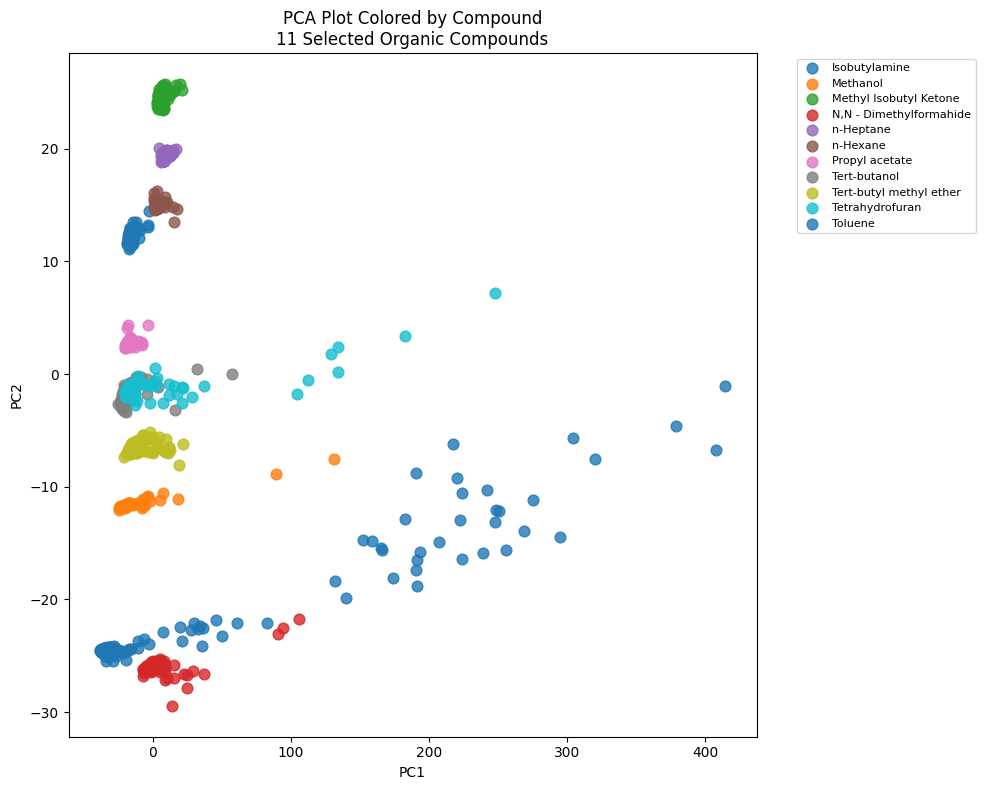


Files saved:
- cluster_composition_11_compounds.csv
- kmeans_clusters_pca_11_compounds.png
- pca_compounds_clustering_11_compounds.png


In [25]:
# ============================================================
# 13. CLUSTERING
# Corrected to include all 11 selected compounds
# ============================================================

target_compounds = [
    "Isobutylamine",
    "Methanol",
    "Methyl Isobutyl Ketone",
    "N,N - Dimethylformahide",
    "n-Heptane",
    "n-Hexane",
    "Propyl acetate",
    "Tert-butanol",
    "Tert-butyl methyl ether",
    "Tetrahydrofuran",
    "Toluene"
]

# ============================================================
# CREATE CLUSTERING DATAFRAME USING PCA RESULTS
# Use X_pca and y_pca from corrected PCA step
# ============================================================

pca_cluster_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PC3": X_pca[:, 2],
    "PC4": X_pca[:, 3],
    "PC5": X_pca[:, 4],
    "Compound": y_pca
})

pca_cluster_df = pca_cluster_df[
    pca_cluster_df["Compound"].isin(target_compounds)
].copy()

print("\nCompounds included in clustering:")
print(pca_cluster_df["Compound"].value_counts())

print("\nNumber of compounds included:")
print(pca_cluster_df["Compound"].nunique())

missing = set(target_compounds) - set(pca_cluster_df["Compound"].unique())

if len(missing) > 0:
    print("\nWARNING: These compounds are missing:")
    print(sorted(missing))

# ============================================================
# PREPARE PCA COORDINATES FOR CLUSTERING
# ============================================================

X_cluster = pca_cluster_df[
    ["PC1", "PC2", "PC3", "PC4", "PC5"]
].values

y_cluster = pca_cluster_df["Compound"].values

# Force 11 clusters because there are 11 compounds of interest
n_clusters = 11

# ============================================================
# K-MEANS CLUSTERING
# ============================================================

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_cluster)

pca_cluster_df["Cluster"] = clusters

# ============================================================
# CLUSTER COMPOSITION TABLE
# ============================================================

cluster_composition = pd.crosstab(
    pca_cluster_df["Cluster"],
    pca_cluster_df["Compound"]
)

print("\nCluster composition:")
print(cluster_composition)

cluster_composition.to_csv(
    "cluster_composition_11_compounds.csv"
)

# ============================================================
# SILHOUETTE SCORE
# ============================================================

silhouette = silhouette_score(
    X_cluster,
    clusters
)

print("\nSilhouette score:")
print(silhouette)

# ============================================================
# PLOT CLUSTERS ON PCA SPACE
# ============================================================

plt.figure(figsize=(10, 8))

for cluster in sorted(pca_cluster_df["Cluster"].unique()):

    subset = pca_cluster_df[
        pca_cluster_df["Cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        s=60,
        alpha=0.8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "K-means Clustering on PCA Scores\n11 Selected Organic Compounds"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "kmeans_clusters_pca_11_compounds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PLOT PCA COLORED BY COMPOUND
# ============================================================

plt.figure(figsize=(10, 8))

for compound in target_compounds:

    subset = pca_cluster_df[
        pca_cluster_df["Compound"] == compound
    ]

    if subset.shape[0] > 0:

        plt.scatter(
            subset["PC1"],
            subset["PC2"],
            label=compound,
            s=60,
            alpha=0.8
        )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "PCA Plot Colored by Compound\n11 Selected Organic Compounds"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "pca_compounds_clustering_11_compounds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFiles saved:")
print("- cluster_composition_11_compounds.csv")
print("- kmeans_clusters_pca_11_compounds.png")
print("- pca_compounds_clustering_11_compounds.png")

In [26]:
#
# ============================================================
# 14. PREDICTIVE MACHINE LEARNING
# Classification of selected compounds only
# ============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# ------------------------------------------------------------
# COMPOUNDS OF INTEREST
# Use exact names as they appear in your dataset
# ------------------------------------------------------------

target_compounds = [
    "Isobutylamine",
    "Methanol",
    "Methyl Isobutyl Ketone",
    "N,N - Dimethylformahide",
    "n-Heptane",
    "n-Hexane",
    "Propyl acetate",
    "Tert-butanol",
    "Tert-butyl methyl ether",
    "Tetrahydrofuran",
    "Toluene"
]

# ------------------------------------------------------------
# CREATE MACHINE LEARNING DATAFRAME
# ------------------------------------------------------------

ml_df = pd.DataFrame(
    X_norm,
    columns=raman_cols
)

ml_df["Compound"] = y

# Keep only selected compounds
ml_df = ml_df[
    ml_df["Compound"].isin(target_compounds)
].copy()

print("\nCompounds included in machine learning:")
print(ml_df["Compound"].value_counts())

print("\nNumber of compounds included:")
print(ml_df["Compound"].nunique())

# ------------------------------------------------------------
# EXTRACT FEATURES AND LABELS
# ------------------------------------------------------------

X_ml = ml_df[raman_cols].values
y_ml = ml_df["Compound"].values

# ------------------------------------------------------------
# ENCODE LABELS
# ------------------------------------------------------------

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_ml)

print("\nEncoded classes:")
print(encoder.classes_)

# ------------------------------------------------------------
# TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_ml,
    y_encoded,
    test_size=0.25,
    stratify=y_encoded,
    random_state=42
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# ============================================================
# DEFINE MACHINE LEARNING MODELS
# ============================================================

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced"
    ),

    "Support Vector Machine": SVC(
        kernel="rbf",
        C=10,
        gamma="scale"
    ),

    "K-Nearest Neighbours": KNeighborsClassifier(
        n_neighbors=5
    )
}

# ============================================================
# TRAIN AND EVALUATE MODELS
# ============================================================

results = []

for name, model in models.items():

    print("\n================================================")
    print("Model:", name)
    print("================================================")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    print("Accuracy:", round(acc, 4))
    print("Weighted F1:", round(f1, 4))

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=encoder.classes_
        )
    )

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Weighted_F1": f1
    })

# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Weighted_F1",
    ascending=False
)

print("\n================================================")
print("MODEL COMPARISON")
print("================================================")

print(results_df)

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

results_df.to_csv(
    "model_performance_selected_compounds.csv",
    index=False
)

results_df.to_excel(
    "model_performance_selected_compounds.xlsx",
    index=False
)

print("\nFiles saved:")
print("- model_performance_selected_compounds.csv")
print("- model_performance_selected_compounds.xlsx")


Compounds included in machine learning:
Compound
Toluene                    127
Tert-butyl methyl ether    117
Tert-butanol               113
Propyl acetate             107
Methyl Isobutyl Ketone     105
N,N - Dimethylformahide    105
Isobutylamine              104
n-Heptane                  103
n-Hexane                   102
Methanol                   101
Tetrahydrofuran            100
Name: count, dtype: int64

Number of compounds included:
11

Encoded classes:
['Isobutylamine' 'Methanol' 'Methyl Isobutyl Ketone'
 'N,N - Dimethylformahide' 'Propyl acetate' 'Tert-butanol'
 'Tert-butyl methyl ether' 'Tetrahydrofuran' 'Toluene' 'n-Heptane'
 'n-Hexane']

Training set shape: (888, 3276)
Test set shape: (296, 3276)

Model: Random Forest
Accuracy: 1.0
Weighted F1: 1.0

Classification report:
                         precision    recall  f1-score   support

          Isobutylamine       1.00      1.00      1.00        26
               Methanol       1.00      1.00      1.00        25
 Meth

Este código faz uma análise de machine learning supervisionado para classificar os espectros Raman nos 11 compostos orgânicos selecionados. O código usa as intensidades Raman para prever qual é o composto químico. 

O código testa três modelos - Random Forest, Support Vector Machine	e K-Nearest Neighbours e tenta avaliar qual é o modelo que consegue identificar melhor o composto químico a partir dos seus espectros Raman.


Compounds included in confusion matrix:
Compound
Toluene                    127
Tert-butyl methyl ether    117
Tert-butanol               113
Propyl acetate             107
Methyl Isobutyl Ketone     105
N,N - Dimethylformahide    105
Isobutylamine              104
n-Heptane                  103
n-Hexane                   102
Methanol                   101
Tetrahydrofuran            100
Name: count, dtype: int64

Number of compounds included:
11

All 11 compounds included.

Best model:
Random Forest

Confusion matrix table:
                         Isobutylamine  Methanol  Methyl Isobutyl Ketone  \
Isobutylamine                       26         0                       0   
Methanol                             0        25                       0   
Methyl Isobutyl Ketone               0         0                      26   
N,N - Dimethylformahide              0         0                       0   
Propyl acetate                       0         0                       0   
Tert-butanol 

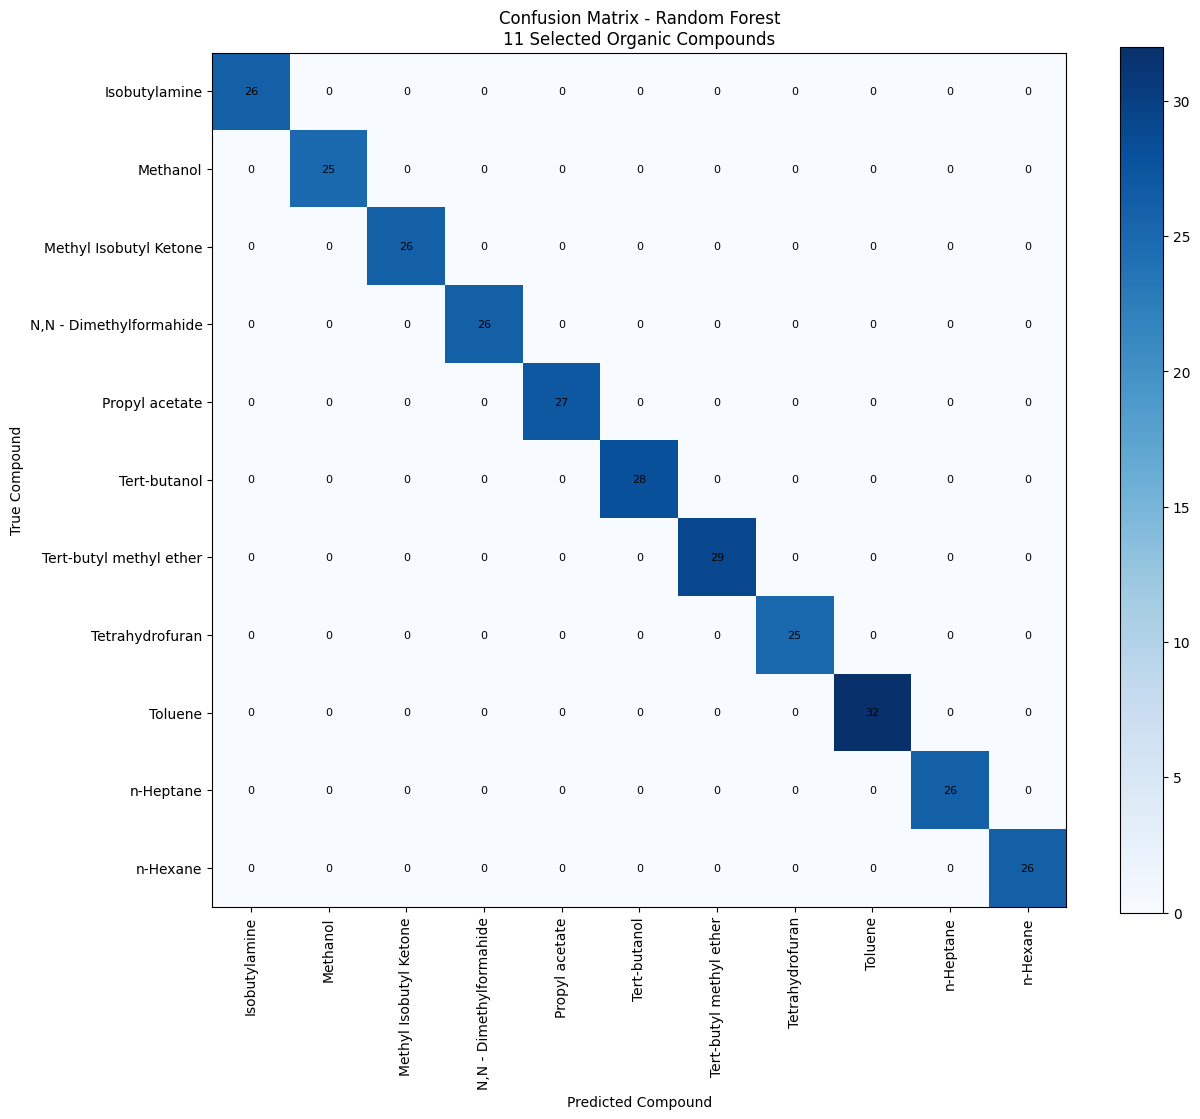


Files saved:
- confusion_matrix_11_compounds.csv
- confusion_matrix_11_compounds.png


In [27]:
# ============================================================
# 15. CONFUSION MATRIX FOR BEST MODEL
# Corrected to include all 11 selected compounds
# ============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# COMPOUNDS OF INTEREST
# Exact names as they appear in the dataset
# ============================================================

target_compounds = [
    "Isobutylamine",
    "Methanol",
    "Methyl Isobutyl Ketone",
    "N,N - Dimethylformahide",
    "n-Heptane",
    "n-Hexane",
    "Propyl acetate",
    "Tert-butanol",
    "Tert-butyl methyl ether",
    "Tetrahydrofuran",
    "Toluene"
]

# ============================================================
# CREATE DATAFRAME USING X_norm AND y FROM CORRECTED SECTION 5
# ============================================================

confusion_df = pd.DataFrame(
    X_norm,
    columns=raman_cols
)

confusion_df["Compound"] = y

confusion_df = confusion_df[
    confusion_df["Compound"].isin(target_compounds)
].copy()

print("\nCompounds included in confusion matrix:")
print(confusion_df["Compound"].value_counts())

print("\nNumber of compounds included:")
print(confusion_df["Compound"].nunique())

missing = set(target_compounds) - set(confusion_df["Compound"].unique())

if len(missing) > 0:
    print("\nWARNING: These compounds are missing:")
    print(sorted(missing))
    print("\nYou must rerun Section 5 preprocessing first using the corrected compound names.")
else:
    print("\nAll 11 compounds included.")

# ============================================================
# EXTRACT FEATURES AND LABELS
# ============================================================

X_conf = confusion_df[raman_cols].values
y_conf = confusion_df["Compound"].values

encoder = LabelEncoder()
y_encoded_conf = encoder.fit_transform(y_conf)

# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_conf,
    y_encoded_conf,
    test_size=0.25,
    stratify=y_encoded_conf,
    random_state=42
)

# ============================================================
# IDENTIFY BEST MODEL FROM SECTION 14
# ============================================================

best_model_name = results_df.sort_values(
    "Weighted_F1",
    ascending=False
).iloc[0]["Model"]

print("\nBest model:")
print(best_model_name)

best_model = models[best_model_name]

# ============================================================
# TRAIN BEST MODEL AGAIN ON THE 11-COMPOUND DATASET
# ============================================================

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred_best,
    labels=np.arange(len(encoder.classes_))
)

cm_df = pd.DataFrame(
    cm,
    index=encoder.classes_,
    columns=encoder.classes_
)

print("\nConfusion matrix table:")
print(cm_df)

cm_df.to_csv(
    "confusion_matrix_11_compounds.csv"
)

# ============================================================
# PLOT CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(13, 11))

plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(
    range(len(encoder.classes_)),
    encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(encoder.classes_)),
    encoder.classes_
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )

plt.xlabel("Predicted Compound")
plt.ylabel("True Compound")

plt.title(
    f"Confusion Matrix - {best_model_name}\n11 Selected Organic Compounds"
)

plt.tight_layout()

plt.savefig(
    "confusion_matrix_11_compounds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFiles saved:")
print("- confusion_matrix_11_compounds.csv")
print("- confusion_matrix_11_compounds.png")

O modelo Random Forest conseguiu classificar corretamente a maioria dos espectros Raman dos compostos selecionados. A matriz de confusão (“confusion matrix”) mostra nas linhas os compostos reais e nas colunas os compostos previstos pelo modelo. Os valores mais altos concentrados na diagonal principal indicam forte capacidade discriminativa dos espectros Raman e baixa confusão entre compostos.

In [29]:
# ============================================================
# 16. CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_ml,
        y_encoded,
        cv=cv,
        scoring="f1_weighted"
    )

    print(f"\n{name}")
    print("Cross-validation weighted F1:", scores)
    print("Mean F1:", scores.mean())
    print("SD:", scores.std())


Random Forest
Cross-validation weighted F1: [1. 1. 1. 1. 1.]
Mean F1: 1.0
SD: 0.0

Support Vector Machine
Cross-validation weighted F1: [1. 1. 1. 1. 1.]
Mean F1: 1.0
SD: 0.0

K-Nearest Neighbours
Cross-validation weighted F1: [1. 1. 1. 1. 1.]
Mean F1: 1.0
SD: 0.0


Este código realiza uma validação cruzada (cross-validation) para avaliar a robustez dos modelos de machine learning.

Foi realizada validação cruzada estratificada com 5 folds para avaliar a robustez dos modelos de classificação. O desempenho foi medido utilizando o Weighted F1-score. Valores médios elevados e baixa variabilidade entre folds indicaram boa capacidade de generalização e estabilidade dos modelos de machine learning aplicados aos espectros Raman.

Todos os modelos de machine learning apresentaram muito bom desempenho durante a validação cruzada estratificada de 5 folds, obtendo Weighted F1-score médio de 1.0 e desvio padrão de 0.0. Estes resultados indicam elevada capacidade discriminativa dos espectros Raman e forte separação entre os compostos analisados. Isto tinha sido observado no PCA e no t-SNE. 

Contudo, estes resultados podem também sugerir possível overfitting ou elevada similaridade entre espectros de treino e teste, devendo ser interpretados com cautela.

Para testar o overfitting

In [31]:
# ============================================================
# 17. TESTES DE POSSÍVEL OVERFITTING — VERSÃO RÁPIDA
# ============================================================

from sklearn.model_selection import cross_val_score, StratifiedKFold, permutation_test_score
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

X_overfit = X_ml
y_overfit = y_encoded

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# 1. COMPARAÇÃO TREINO / TESTE
# ============================================================

overfit_results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_f1 = f1_score(y_train, y_train_pred, average="weighted")
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")

    overfit_results.append({
        "Model": name,
        "Train_F1": train_f1,
        "Test_F1": test_f1,
        "Train_Test_Gap": train_f1 - test_f1
    })

overfit_df = pd.DataFrame(overfit_results)

print("\nTrain/Test comparison:")
print(overfit_df)

# ============================================================
# 2. PERMUTATION TEST — APENAS RANDOM FOREST, MAIS RÁPIDO
# ============================================================

rf_model = models["Random Forest"]

score, permutation_scores, pvalue = permutation_test_score(
    rf_model,
    X_overfit,
    y_overfit,
    scoring="f1_weighted",
    cv=cv,
    n_permutations=10,
    random_state=42,
    n_jobs=-1
)

print("\nPermutation test: Random Forest")
print("Real weighted F1:", score)
print("Mean permutation F1:", permutation_scores.mean())
print("Permutation p-value:", pvalue)

# ============================================================
# 3. RANDOM LABEL TEST
# ============================================================

rng = np.random.default_rng(42)
y_random = rng.permutation(y_overfit)

print("\nRandom-label test:")

for name, model in models.items():

    scores_random = cross_val_score(
        model,
        X_overfit,
        y_random,
        cv=cv,
        scoring="f1_weighted",
        n_jobs=-1
    )

    print("\n", name)
    print("Random-label F1 scores:", scores_random)
    print("Mean random-label F1:", scores_random.mean())
    print("SD:", scores_random.std())

print("\nOverfitting tests complete.")


Train/Test comparison:
                    Model  Train_F1  Test_F1  Train_Test_Gap
0           Random Forest       1.0      1.0             0.0
1  Support Vector Machine       1.0      1.0             0.0
2    K-Nearest Neighbours       1.0      1.0             0.0

Permutation test: Random Forest
Real weighted F1: 1.0
Mean permutation F1: 0.09052386034764
Permutation p-value: 0.09090909090909091

Random-label test:

 Random Forest
Random-label F1 scores: [0.09039486 0.08312803 0.08664416 0.11945105 0.09582933]
Mean random-label F1: 0.09508948688493715
SD: 0.012887766392430404

 Support Vector Machine
Random-label F1 scores: [0.09720823 0.08262399 0.07460906 0.0859467  0.08521002]
Mean random-label F1: 0.08511960003821113
SD: 0.00725984605081629

 K-Nearest Neighbours
Random-label F1 scores: [0.06273393 0.09853951 0.07748426 0.09051487 0.04701316]
Mean random-label F1: 0.0752571470841806
SD: 0.018624611057183407

Overfitting tests complete.


Os testes de overfitting indicaram ausência de evidência forte de sobreajuste dos modelos. O desempenho foi consistente entre treino e teste (Weighted F1 = 1.0), sem diferença entre ambos. Nos testes com labels aleatórios e permutation tests, o desempenho caiu para valores próximos do acaso (~0.09), sugerindo que os modelos aprenderam padrões espectrais reais e não ruído aleatório. Estes resultados indicam elevada capacidade discriminativa dos espectros Raman para os compostos analisados, embora a performance perfeita deva ser interpretada com cautela devido à possível similaridade entre réplicas espectrais.


Top Raman shifts according to Random Forest:
      Raman_shift  Importance
2771       2921.0    0.005115
2726       2876.0    0.004647
2789       2939.0    0.004469
2790       2940.0    0.004307
2712       2862.0    0.004261
2713       2863.0    0.004198
2705       2855.0    0.003844
2727       2877.0    0.003840
2711       2861.0    0.003643
2707       2857.0    0.003619
884        1034.0    0.003474
880        1030.0    0.003473
2700       2850.0    0.003360
2720       2870.0    0.003328
2706       2856.0    0.003311
2710       2860.0    0.003292
2732       2882.0    0.003282
2791       2941.0    0.003252
2676       2826.0    0.003250
2826       2976.0    0.003223
2683       2833.0    0.003196
2830       2980.0    0.003164
773         923.0    0.003118
2762       2912.0    0.003065
2824       2974.0    0.003064
758         908.0    0.003054
2801       2951.0    0.003037
2756       2906.0    0.003030
2729       2879.0    0.003024
2728       2878.0    0.002988


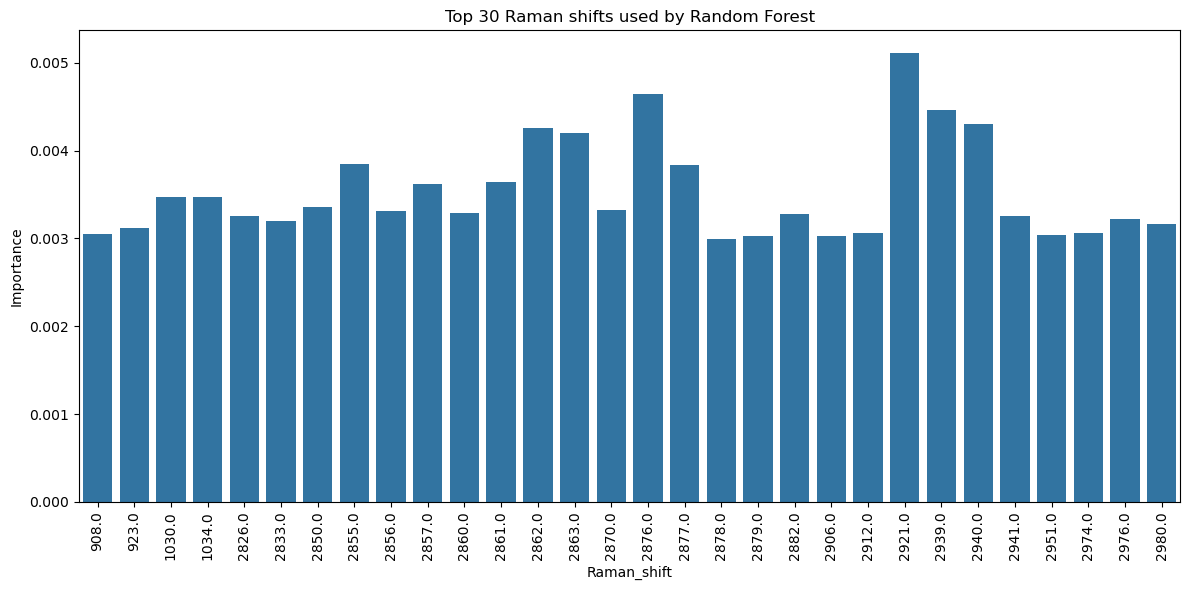

In [39]:
# ============================================================
# 17. VARIABLE IMPORTANCE
# Raman shifts most useful for classification
# ============================================================

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Raman_shift": raman_shifts,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.to_csv("random_forest_variable_importance.csv", index=False)

print("\nTop Raman shifts according to Random Forest:")
print(importance_df.head(30))

plt.figure(figsize=(12, 6))
sns.barplot(
    data=importance_df.head(30),
    x="Raman_shift",
    y="Importance"
)
plt.xticks(rotation=90)
plt.title("Top 30 Raman shifts used by Random Forest")
plt.tight_layout()
plt.savefig("top_variable_importance_rf.png", dpi=300)
plt.show()

Este código calcula a importância das variáveis Raman Shift no modelo Random Forest. Ou seja, identifica quais regiões do espectro Raman foram mais importantes para distinguir os compostos químicos. No gráfico estão indicadas as 30 Raman Shift contribuiu para o Random Forest distinguir os compostos. Valores maiores significam maior poder discriminativo e maior relevância para classificação. Cada barra corresponde a um Raman Shift específico (cm⁻¹). 

9. seleção ou importância das variáveis usadas pelos modelos, relacionando-as sempre
que possível com regiões relevantes do espectro Raman

In [40]:
# ============================================================
# 18. INTERPRETATION HELPER:
# Relate important shifts to general Raman regions
# ============================================================

def assign_raman_region(shift):
    if 2800 <= shift <= 3100:
        return "C-H stretching region"
    elif 1600 <= shift <= 1700:
        return "C=C / C=O stretching region"
    elif 1000 <= shift <= 1300:
        return "C-C / C-O / C-N fingerprint region"
    elif 700 <= shift <= 1000:
        return "Ring, skeletal or C-C vibration region"
    elif 400 <= shift < 700:
        return "Low-frequency skeletal vibrations"
    else:
        return "Other / compound-specific fingerprint region"

importance_df["Tentative_region"] = importance_df["Raman_shift"].apply(assign_raman_region)

importance_df.head(50).to_csv(
    "top_raman_bands_with_tentative_assignment.csv",
    index=False
)

print("\nTop bands with tentative Raman-region assignment:")
print(importance_df.head(30))


Top bands with tentative Raman-region assignment:
      Raman_shift  Importance                        Tentative_region
2771       2921.0    0.005115                   C-H stretching region
2726       2876.0    0.004647                   C-H stretching region
2789       2939.0    0.004469                   C-H stretching region
2790       2940.0    0.004307                   C-H stretching region
2712       2862.0    0.004261                   C-H stretching region
2713       2863.0    0.004198                   C-H stretching region
2705       2855.0    0.003844                   C-H stretching region
2727       2877.0    0.003840                   C-H stretching region
2711       2861.0    0.003643                   C-H stretching region
2707       2857.0    0.003619                   C-H stretching region
884        1034.0    0.003474      C-C / C-O / C-N fingerprint region
880        1030.0    0.003473      C-C / C-O / C-N fingerprint region
2700       2850.0    0.003360          

O gráfico de importância das variáveis do modelo Random Forest mostrou que determinados Raman Shift contribuíram mais fortemente para a classificação dos compostos. 
As bandas mais importantes localizaram-se sobretudo em regiões associadas à fingerprint region e às vibrações C–H, indicando elevado valor discriminativo destas regiões espectrais.

Conclusão:

As regiões espectrais mais relevantes identificadas pelas análises localizaram-se principalmente na fingerprint region (~600–1800 cm⁻¹) e na região de estiramento C–H (~2800–3100 cm⁻¹). 

Bandas associadas a vibrações C=O mostraram-se importantes para compostos carbonílicos, enquanto bandas aromáticas próximas de ~1600 cm⁻¹ contribuíram para a discriminação do tolueno. Regiões associadas a vibrações C–O e O–H foram particularmente relevantes para álcoois e éteres.

In [41]:
# ============================================================
# 19. SAVE PREPROCESSED DATA
# ============================================================

preprocessed_output = pd.DataFrame(X_norm, columns=raman_cols)
preprocessed_output["label"] = y
preprocessed_output.to_csv("preprocessed_raman_data_selected_compounds.csv", index=False)

print("\nAnalysis complete.")
print("Main output files generated:")
print("- raman_summary_statistics.csv")
print("- mean_spectra_by_compound.csv")
print("- most_variable_raman_bands.csv")
print("- important_pca_bands.csv")
print("- model_performance.csv")
print("- random_forest_variable_importance.csv")
print("- top_raman_bands_with_tentative_assignment.csv")
print("- preprocessed_raman_data_selected_compounds.csv")


Analysis complete.
Main output files generated:
- raman_summary_statistics.csv
- mean_spectra_by_compound.csv
- most_variable_raman_bands.csv
- important_pca_bands.csv
- model_performance.csv
- random_forest_variable_importance.csv
- top_raman_bands_with_tentative_assignment.csv
- preprocessed_raman_data_selected_compounds.csv
